In [1]:
import sys
import os
current_dir = os.path.abspath('')
os.chdir(current_dir)
sys.path.append(os.path.join(current_dir,'..','code','BalancingControl'))

import two_stage_utils as tu
import inference as inf
import inference_utils as iu

torch threads 1
Running on device cpu
torch threads 1


In [2]:
import torch
import pyro

import pyro.distributions as dist

from scipy.io import loadmat
from scipy.stats import ttest_1samp, mannwhitneyu
import matplotlib.pylab as plt
import seaborn as sns
import pandas as pd
import glob
import pickle
import json
import gc
from statannotations.Annotator import Annotator
import numpy as np

from scipy.stats import pearsonr
from statsmodels.stats.multitest import multipletests

In [3]:
results_folder = "results"
inference_folder = os.path.join(results_folder, "inference")
model_comp_folder = os.path.join(results_folder, "model_comparison")

mask_file_name = "mask.txt"
processed_data_folder = "processed_data"
mask_file = os.path.join(processed_data_folder, mask_file_name)

non_fit_fname = "non_fit_file.txt"
non_fit_file = os.path.join(model_comp_folder, non_fit_fname)

full_data_fname = "full_data.csv"
full_data_file = os.path.join(processed_data_folder, full_data_fname)

full_data_df = pd.read_csv(full_data_file)

n_agents = 188

In [4]:
trials =  201#number of trials
T = 3 #number of time steps in each trial
nb = 4 # number of bandits, ie second level rewards
ns = 3+nb #number of states
no = ns #number of observations
na = 2 #number of actions
npi = na**(T-1) #number of policies
nr = 2 #number of rewards
never_reward = ns-nb # states that dont generate rewards

# prob for invalid answer (e.g. no reply). Same frequency as in the real data
# prob for invalid answer (e.g. no reply). Same frequency as in the real data
with open(mask_file, "rb") as f:
    all_mask = pickle.load(f)
# simulations will be done with the same missing actions as in the data.
exp_mask = torch.tensor(all_mask).permute((1,0))
p_valid = exp_mask.sum()/(exp_mask.shape[0]*exp_mask.shape[1])
print(p_valid)

# make global parameter dict:
global_experiment_parameters = {"trials": trials, "T": T, "nb": nb, "ns": ns, "no": no, "na": na, "npi": npi, "nr": nr, "never_reward": never_reward, "p_invalid": p_valid, "mask": exp_mask}

tensor(0.9766)


/tmp/ipykernel_3002/1548601007.py:16: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index
  exp_mask = torch.tensor(all_mask).permute((1,0))


In [5]:
#generating probability of observations in each state / unity matrix
A = torch.eye(no)


#state transition generative probability (matrix)
B = torch.zeros((ns, ns, na))
b1 = 0.7
nb1 = 1.-b1
b2 = 0.7
nb2 = 1.-b2

B[:,:,0] = torch.tensor([[  0,  0,  0,  0,  0,  0,  0,],
                         [ b1,  0,  0,  0,  0,  0,  0,],
                         [nb1,  0,  0,  0,  0,  0,  0,],
                         [  0,  1,  0,  1,  0,  0,  0,],
                         [  0,  0,  1,  0,  1,  0,  0,],
                         [  0,  0,  0,  0,  0,  1,  0,],
                         [  0,  0,  0,  0,  0,  0,  1,],])

B[:,:,1] = torch.tensor([[  0,  0,  0,  0,  0,  0,  0,],
                         [nb2,  0,  0,  0,  0,  0,  0,],
                         [ b2,  0,  0,  0,  0,  0,  0,],
                         [  0,  0,  0,  1,  0,  0,  0,],
                         [  0,  0,  0,  0,  1,  0,  0,],
                         [  0,  1,  0,  0,  0,  1,  0,],
                         [  0,  0,  1,  0,  0,  0,  1,],])

# add to parameter dict
global_experiment_parameters["A"] = A
global_experiment_parameters["B"] = B

In [6]:
def convert_data_for_agent(full_data_df):

    mask = full_data_df.loc[(full_data_df["step_index"]==1)]
    mask_formatted = torch.stack([torch.from_numpy(mask.loc[mask["subject"]==i]["mask"].to_numpy()) for i in range(n_agents)])

    actions1 = full_data_df.loc[(full_data_df["step_index"]==1)]
    actions1_formatted = torch.stack([torch.from_numpy(actions1.loc[actions1["subject"]==i]["first_stage_actions"].to_numpy()) for i in range(n_agents)])

    actions2 = full_data_df.loc[(full_data_df["step_index"]==2)]
    actions2_formatted = torch.stack([torch.from_numpy(actions2.loc[actions2["subject"]==i]["second_stage_actions"].to_numpy()) for i in range(n_agents)])

    print("possible actions1", torch.unique(actions1_formatted[mask_formatted]))
    print("possible actions2", torch.unique(actions2_formatted[mask_formatted]))

    # write minus one into invalid regions (currently returns integer overflow below when converted to int)
    actions1_formatted = torch.where(mask_formatted, actions1_formatted, -1)
    actions2_formatted = torch.where(mask_formatted, actions2_formatted, -1)

    actions = torch.stack([actions1_formatted, actions2_formatted], dim=-1).permute((1,2,0))
    #print(actions.permute((0,2,1))[mask_formatted])
    # agent counts from zero:
    actions = actions-1.

    states1 = full_data_df.loc[(full_data_df["step_index"]==1)]
    # agent counts from zero, hence -1 at the end:
    states1_formatted = torch.stack([torch.from_numpy(states1.loc[states1["subject"]==i]["first_stage_states"].to_numpy()) for i in range(n_agents)]) - 1
     
    states2 = full_data_df.loc[(full_data_df["step_index"]==2)]
    # agent counts from zero, hence -1 at the end:
    states2_formatted = torch.stack([torch.from_numpy(states2.loc[states2["subject"]==i]["second_stage_states"].to_numpy()) for i in range(n_agents)]) - 1

    # write minus one into invalid regions (currently returns integer overflow below when converted to int)
    states1_formatted = torch.where(mask_formatted, states1_formatted, -1)
    states2_formatted = torch.where(mask_formatted, states2_formatted, -1)
    # create third time step states:
    states3_formatted = states2_formatted+2 + (actions2_formatted-1)*2
    states3_formatted = torch.where(mask_formatted, states3_formatted, -1)


    print("possible states1", torch.unique(states1_formatted[mask_formatted]))
    print("possible states2", torch.unique(states2_formatted[mask_formatted]))
    print("possible states3", torch.unique(states3_formatted[mask_formatted]))

    states = torch.stack([states1_formatted, states2_formatted, states3_formatted], dim=-1).permute((1,2,0))

    # agent views r=2 as "no reward", may instead give negative reward as in Otto et al:
    rewards1_formatted = torch.zeros_like(states1_formatted) #+ 2

    rewards2_formatted = rewards1_formatted

    # create third time step rewards = second stage rewards:
    rewards3 = full_data_df.loc[(full_data_df["step_index"]==2)]
    rewards3_formatted = torch.stack([torch.from_numpy(rewards3.loc[rewards3["subject"]==i]["second_stage_rewards"].to_numpy()) for i in range(n_agents)])

    print("possible rewards1", torch.unique(rewards1_formatted[mask_formatted]))
    print("possible rewards2", torch.unique(rewards2_formatted[mask_formatted]))
    print("possible rewards3", torch.unique(rewards3_formatted[mask_formatted]))

    # write minus one into invalid regions (currently returns integer overflow below when converted to int)
    rewards1_formatted = torch.where(mask_formatted, rewards1_formatted, 0)
    rewards2_formatted = torch.where(mask_formatted, rewards2_formatted, 0)
    rewards3_formatted = torch.where(mask_formatted, rewards3_formatted, 0)

    rewards = torch.stack([rewards1_formatted, rewards2_formatted, rewards3_formatted], dim=-1).permute((1,2,0))


    data_dict = {"observations": states.long(), "rewards": rewards.long(), "actions": actions.long(), "valid": mask_formatted.permute((1,0))}

    return data_dict

data = convert_data_for_agent(full_data_df)

print(data)

possible actions1 tensor([1., 2.], dtype=torch.float64)
possible actions2 tensor([1., 2.], dtype=torch.float64)
possible states1 tensor([0.], dtype=torch.float64)
possible states2 tensor([1., 2.], dtype=torch.float64)
possible states3 tensor([3., 4., 5., 6.], dtype=torch.float64)
possible rewards1 tensor([0.], dtype=torch.float64)
possible rewards2 tensor([0.], dtype=torch.float64)
possible rewards3 tensor([0., 1.], dtype=torch.float64)
{'observations': tensor([[[ 0,  0,  0,  ..., -1,  0, -1],
         [ 1,  1,  2,  ..., -1,  1, -1],
         [ 3,  3,  4,  ..., -1,  5, -1]],

        [[ 0,  0,  0,  ...,  0,  0,  0],
         [ 1,  1,  2,  ...,  1,  1,  2],
         [ 5,  3,  6,  ...,  3,  3,  4]],

        [[ 0,  0,  0,  ...,  0,  0,  0],
         [ 1,  1,  2,  ...,  2,  2,  1],
         [ 5,  3,  6,  ...,  6,  6,  3]],

        ...,

        [[ 0,  0,  0,  ...,  0,  0,  0],
         [ 1,  1,  2,  ...,  1,  2,  1],
         [ 3,  5,  4,  ...,  3,  6,  3]],

        [[ 0,  0, -1,  ..., 

In [7]:
def load_BCC_results(learn_rewards, learn_habit, learn_cached, base_dir, global_experiment_parameters, valid, fname_base, num_steps, data, param_names, use_h=False):    

    # set up agent
    bayes_agent = tu.set_up_Bayesian_inference_agent(n_agents, learn_rewards, learn_habit, learn_cached, base_dir, 
                                                    global_experiment_parameters, data["valid"], remove_old=False, 
                                                    use_h=use_h)

    print('analyzing '+str(n_agents)+' data sets')

    resample = False

    # set up inference
    inferrer = inf.GeneralGroupInference(bayes_agent, data)

    fname_str = fname_base + str(num_steps)+'_'+str(n_agents)+'agents'

    inferrer.load_parameters(os.path.join(base_dir, fname_str+"_parameter.save"))

    inferrer.load_elbo(os.path.join(base_dir, fname_str+"_elbo.save"))

    if resample:
        mean_df, sample_df, locs_sample_df = iu.sample_posterior(inferrer, param_names, fname_str, base_dir) 
    else:
        mean_df, sample_df, locs_sample_df = iu.load_samples(base_dir, fname_str) 

    return mean_df, sample_df, locs_sample_df

In [8]:
def load_MFMB_results(use_orig, learn_prior, use_p, restrict_alpha, max_dt, base_dir, global_experiment_parameters, valid, fname_base, num_steps, data, param_names):    

    # set up agent
    mfmb_agent = tu.set_up_mbmf_inference_agent(n_agents, learn_prior, use_orig, use_p, restrict_alpha, max_dt, 0, base_dir, global_experiment_parameters, valid, remove_old=False)

    print('analyzing '+str(n_agents)+' data sets')

    resample = False

    # set up inference
    inferrer = inf.GeneralGroupInference(mfmb_agent, data)

    fname_str = fname_base + str(num_steps)+'_'+str(n_agents)+'agents'

    inferrer.load_parameters(os.path.join(base_dir, fname_str+"_parameter.save"))

    inferrer.load_elbo(os.path.join(base_dir, fname_str+"_elbo.save"))

    if resample:
        mean_df, sample_df, locs_sample_df = iu.sample_posterior(inferrer, param_names, fname_str, base_dir) 
    else:
        mean_df, sample_df, locs_sample_df = iu.load_samples(base_dir, fname_str) 

    return mean_df, sample_df, locs_sample_df

In [9]:
def calculate_log_likelihood(data, agent, locs_df, npars, trials, T):

    # question: what do with nan trials? If I ignore them, they will decrease the likelihood and make subject seem to fit better. If I make them uniform, itll decrease by a lot?
    # this is the likelihood of the average parameter

    n_agents = data["actions"].shape[-1]
    log_like = torch.zeros(n_agents)
    
    locs_list = []
    for k in range(npars):
        locs_subs = []
        for i in range(n_agents):
            locs_subs.append(locs_df[locs_df["subject"]==i]["locs"+str(k)].mean())
        locs_list.append(torch.tensor(locs_subs).float())

    locs = torch.stack(locs_list, dim=-1)
    
    assert(locs.shape[0]==n_agents)

    agent.reset(locs)

    for tau in pyro.markov(range(trials)):
        for t in range(T):

            if t==0:
                prev_response = None
                context = None
            else:
                prev_response = data["actions"][tau, t-1]
                context = None

            observation = data["observations"][tau, t]

            reward = data["rewards"][tau, t]

            agent.update_beliefs(tau, t, observation, reward, prev_response, context)

            if t < T-1:

                probs = agent.perception.posterior_actions[-1]
                if torch.any(torch.isnan(probs)):
                    print(probs)
                    #print(param_dict)
                    print(tau,t)

                curr_response = data["actions"][tau, t]*data["valid"][tau].long()

                one_hot_responses = torch.nn.functional.one_hot(curr_response, num_classes=2).permute((1,0))[:,None,:].float()

                likes = (probs * one_hot_responses).sum(dim=0)[0]

                masked_probs = torch.where(data["valid"][tau], likes, torch.tensor([0.5]))

                log_like += torch.log(masked_probs)

    return log_like
    

In [10]:
def calculate_BIC(data, agent, locs_df, npars, trials, T):

    # use bic to circumvent the number of trials problem

    n_agents = data["actions"].shape[-1]
    BIC = torch.zeros(n_agents)
    
    locs_list = []
    for k in range(npars):
        locs_subs = []
        for i in range(n_agents):
            locs_subs.append(locs_df[locs_df["subject"]==i]["locs"+str(k)].mean())
        locs_list.append(torch.tensor(locs_subs).float())

    locs = torch.stack(locs_list, dim=-1)
    
    assert(locs.shape[0]==n_agents)

    agent.reset(locs)

    for tau in pyro.markov(range(trials)):
        for t in range(T):

            if t==0:
                prev_response = None
                context = None
            else:
                prev_response = data["actions"][tau, t-1]
                context = None

            observation = data["observations"][tau, t]

            reward = data["rewards"][tau, t]

            agent.update_beliefs(tau, t, observation, reward, prev_response, context)

            if t < T-1:

                probs = agent.perception.posterior_actions[-1]
                if torch.any(torch.isnan(probs)):
                    print(probs)
                    #print(param_dict)
                    print(tau,t)

                curr_response = data["actions"][tau, t]*data["valid"][tau].long()

                one_hot_responses = torch.nn.functional.one_hot(curr_response, num_classes=2).permute((1,0))[:,None,:].float()

                likes = (probs * one_hot_responses).sum(dim=0)[0]

                masked_probs = torch.where(data["valid"][tau], likes, torch.tensor(0.5))

                print(masked_probs.shape)

                BIC -= 2*torch.log(masked_probs)

    # question: is it noraml that the first term of the BIC (k*ln(n)) is much smaller than the second (-2*ln(L))?
    BIC += npars*torch.log(data["valid"].sum(axis=0))

    return BIC
    

In [11]:
def calculate_lppd(data, agent, locs_df, npars, trials, T, max_samples=-1):

    # question: what do with nan trials? If I ignore them, they will decrease the likelihood and make subject seem to fit better. If I make them uniform, itll decrease by a lot?
    # Eqs (4,5) from here:
    # http://www.stat.columbia.edu/~gelman/research/published/waic_understand3.pdf
    # this is the average likelihood

    n_agents = data["actions"].shape[-1]
    
    locs_list = []
    for k in range(npars):
        locs_subs = []
        for i in range(n_agents):
            locs_subs.append(torch.tensor(locs_df[locs_df["subject"]==i]["locs"+str(k)].values[:max_samples]).float())
        locs_list.append(torch.stack(locs_subs, dim=-1))

    locs = torch.stack(locs_list, dim=-1)

    n_samples = locs.shape[0]

    likelihoods = []

    agent.reset(locs)

    for tau in pyro.markov(range(trials)):
        for t in range(T):

            if t==0:
                prev_response = None
                context = None
            else:
                prev_response = data["actions"][tau, t-1]
                context = None

            observation = data["observations"][tau, t]

            reward = data["rewards"][tau, t]

            agent.update_beliefs(tau, t, observation, reward, prev_response, context)

            if t < T-1:

                probs = agent.perception.posterior_actions[-1]
                #print("probs", probs.shape)
                if torch.any(torch.isnan(probs)):
                    print(probs)
                    #print(param_dict)
                    print(tau,t)

                curr_response = data["actions"][tau, t]*data["valid"][tau].long()

                one_hot_responses = torch.nn.functional.one_hot(curr_response, num_classes=2).permute((1,0))[:,None,:].float()

                likes = (probs * one_hot_responses).sum(dim=0)

                masked_probs = torch.where(data["valid"][tau], likes, torch.tensor([0.5]))
                #print("masked probs", masked_probs.shape)

                likelihoods.append(masked_probs)

                #print(tau,t)

    mean_like = torch.stack(likelihoods, dim=0)
    # print("mean like stacked", mean_like.shape)
    # print(mean_like)

    mean_like = mean_like.sum(dim=-2) / n_samples
    # print("mean like summed", mean_like.shape)
    # print(mean_like)

    mean_log_like = torch.log(mean_like).sum(dim=0)

    #print(mean_log_like)
    # print("mean log like", mean_log_like.shape)
    # print(mean_log_like)

    return mean_log_like.clone().detach()
    

In [12]:
def calculate_waic(data, agent, locs_df, npars, trials, T, max_samples=-1):

    # question: what do with nan trials? If I ignore them, they will decrease the likelihood and make subject seem to fit better. If I make them uniform, itll decrease by a lot?
    # Eqs (12,13) from here:
    # http://www.stat.columbia.edu/~gelman/research/published/waic_understand3.pdf
    # this is the average WAIC
    # are the larger number of params handled correctly?

    n_agents = data["actions"].shape[-1]
    
    locs_list = []
    for k in range(npars):
        locs_subs = []
        for i in range(n_agents):
            locs_subs.append(torch.tensor(locs_df[locs_df["subject"]==i]["locs"+str(k)].values[:max_samples]).float())
        locs_list.append(torch.stack(locs_subs, dim=-1))

    locs = torch.stack(locs_list, dim=-1)

    n_samples = locs.shape[0]

    likelihoods = []

    agent.reset(locs)

    for tau in pyro.markov(range(trials)):
        for t in range(T):

            if t==0:
                prev_response = None
                context = None
            else:
                prev_response = data["actions"][tau, t-1]
                context = None

            observation = data["observations"][tau, t]

            reward = data["rewards"][tau, t]

            agent.update_beliefs(tau, t, observation, reward, prev_response, context)

            if t < T-1:

                probs = agent.perception.posterior_actions[-1]
                #print("probs", probs.shape)
                if torch.any(torch.isnan(probs)):
                    print(probs)
                    #print(param_dict)
                    print(tau,t)

                curr_response = data["actions"][tau, t]*data["valid"][tau].long()

                one_hot_responses = torch.nn.functional.one_hot(curr_response, num_classes=2).permute((1,0))[:,None,:].float()

                likes = (probs * one_hot_responses).sum(dim=0)

                masked_probs = torch.where(data["valid"][tau], likes, torch.tensor([0.5]))
                #print("masked probs", masked_probs.shape)

                likelihoods.append(masked_probs)

                #print(tau,t)



    mean_like = torch.stack(likelihoods, dim=0)
    # print("mean like stacked", mean_like.shape)
    # print(mean_like)

    mean_like_samples = mean_like.sum(dim=-2) / n_samples
    # print("mean like summed", mean_like.shape)
    # print(mean_like)

    lppd = torch.log(mean_like_samples).sum(dim=0)
    # print("mean log like", mean_log_like.shape)
    # print(mean_log_like)

    mean_log_like_samples = torch.log(mean_like.sum(dim=-2)) / n_samples

    V_s = ((torch.log(mean_like) - mean_log_like_samples[:,None,:])**2).sum(dim=-2) / (n_samples-1)

    p_waic = V_s.sum(dim=0)

    ellp_waic = lppd - p_waic

    # text says it needs to be -2 * eq 13.
    # minus is required to make lower better, and the 2 converts it to variance scale

    return ellp_waic.clone().detach()
    

In [13]:
def predictive_accuracy_mean_param(data, agent, locs_df, npars, trials, T):

    n_agents = data["actions"].shape[-1]

    predicted_accuracy = torch.zeros(n_agents)
    
    locs_list = []
    for k in range(npars):
        locs_subs = []
        for i in range(n_agents):
            locs_subs.append(locs_df[locs_df["subject"]==i]["locs"+str(k)].mean())
        locs_list.append(torch.tensor(locs_subs).float())

    locs = torch.stack(locs_list, dim=-1)
    
    assert(locs.shape[0]==n_agents)

    agent.reset(locs)

    num_valid_responses = torch.zeros(data["actions"].shape[-1])

    for tau in pyro.markov(range(trials)):
        for t in range(T):

            if t==0:
                prev_response = None
                context = None
            else:
                prev_response = data["actions"][tau, t-1]
                context = None

            observation = data["observations"][tau, t]

            reward = data["rewards"][tau, t]

            agent.update_beliefs(tau, t, observation, reward, prev_response, context)

            if t < T-1:
                #print(tau,t)

                probs = agent.perception.posterior_actions[-1]
                if torch.any(torch.isnan(probs)):
                    print(probs)
                    #print(param_dict)
                    print(tau,t)

                curr_response = data["actions"][tau, t]#*data["valid"][tau].long()
                #print(curr_response)

                predicted_response = torch.argmax(probs, dim=0)[0]

                #print(probs)

                #print(predicted_response)

                correct_response_predicted = (curr_response == predicted_response).int()

                #print(correct_response_predicted)

                predicted_accuracy += correct_response_predicted

                num_valid_responses += data["valid"][tau]

                #print(num_valid_responses)


    corrected_predicted_accuracy = predicted_accuracy / num_valid_responses

    return corrected_predicted_accuracy

In [14]:
def calculate_exceedance_prob(measure, n_exc_samples=500):
    
    p_model = torch.nn.functional.softmax(measure, dim=-1)

    print("p model mean according to measure", p_model.mean(dim=0))

    dirichlet_counts = p_model.sum(dim=0)

    model_prob_dirichlet = dist.Dirichlet(dirichlet_counts)

    n_exc_samples = 500

    dir_samples = model_prob_dirichlet.sample(sample_shape=torch.tensor([n_exc_samples]))

    avg_best_model = dir_samples.mean(dim=0).argmax()

    best_model = dir_samples.argmax(dim=1)

    exc_prob = (best_model == avg_best_model).sum()/n_exc_samples

    print("best model:", avg_best_model, "exceedance prob", exc_prob)

    significant_best_model = ttest_1samp(dir_samples[:,avg_best_model], 1./measure.shape[-1], alternative="greater")

    print("is significantly different from uniform?", significant_best_model)

    return exc_prob, avg_best_model

### make plot helper function

In [15]:
def plot_correlations(plot_df, x_vars_of_interest, y_vars_of_interest):

    if set(x_vars_of_interest) == set(y_vars_of_interest):
        square = True
        vars_of_interest = x_vars_of_interest
    else:
        square = False
        vars_of_interest = x_vars_of_interest+y_vars_of_interest
    rho = plot_df[vars_of_interest].corr()
    pval = plot_df[vars_of_interest].corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
    reject, pval_corrected, alphaS, alphaB = multipletests(pval, method='bonferroni')

    if square:
        mask = np.triu(np.ones_like(rho, dtype=bool), k=1)
    else:
        mask = np.zeros_like(rho.loc[x_vars_of_interest,y_vars_of_interest], dtype=bool)

    plt.figure()

    alpha_plot = np.where(pval.loc[x_vars_of_interest,y_vars_of_interest]<0.05, 1, 0.1)
    # sns.set(font_scale=1.2)
    g = sns.heatmap(rho.loc[x_vars_of_interest,y_vars_of_interest], annot=rho.loc[x_vars_of_interest,y_vars_of_interest], fmt='.2f', cmap='Spectral_r', alpha=alpha_plot, 
                # palettes: crest, icefire, vlag, Greys, RdGy, RdBu, etc etc, and add _r for reversed
                vmin=-1, vmax=1, mask=mask, annot_kws={"size": 12})#, ax=ax)
    g.set_xticklabels(g.get_xmajorticklabels(), fontsize = 12)
    g.set_yticklabels(g.get_ymajorticklabels(), fontsize = 12)
    cbar = g.collections[0].colorbar
    cbar.ax.tick_params(labelsize=12)

    plt.show()

### Load BCC4 planning+repetition results, and plot correlations between inferred parameters

BCC_4pars_plan_habit_weight_NO_context
BCC_4pars_plan_habit_weight_NO_context_inference_
4
analyzing 188 data sets
4


/home/sarah/src/TwoStageStrategies/Chen_et_al_data/../code/BalancingControl/perception.py:136: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /croot/pytorch-select_1707782759820/work/aten/src/ATen/native/TensorShape.cpp:3637.)
  self.big_trans_matrix = ar.stack([ar.stack([generative_model_states[:,:,policies[pi,t]] for pi in range(self.npi)]) for t in range(self.T-1)]).T.to(device)


<Figure size 640x480 with 0 Axes>

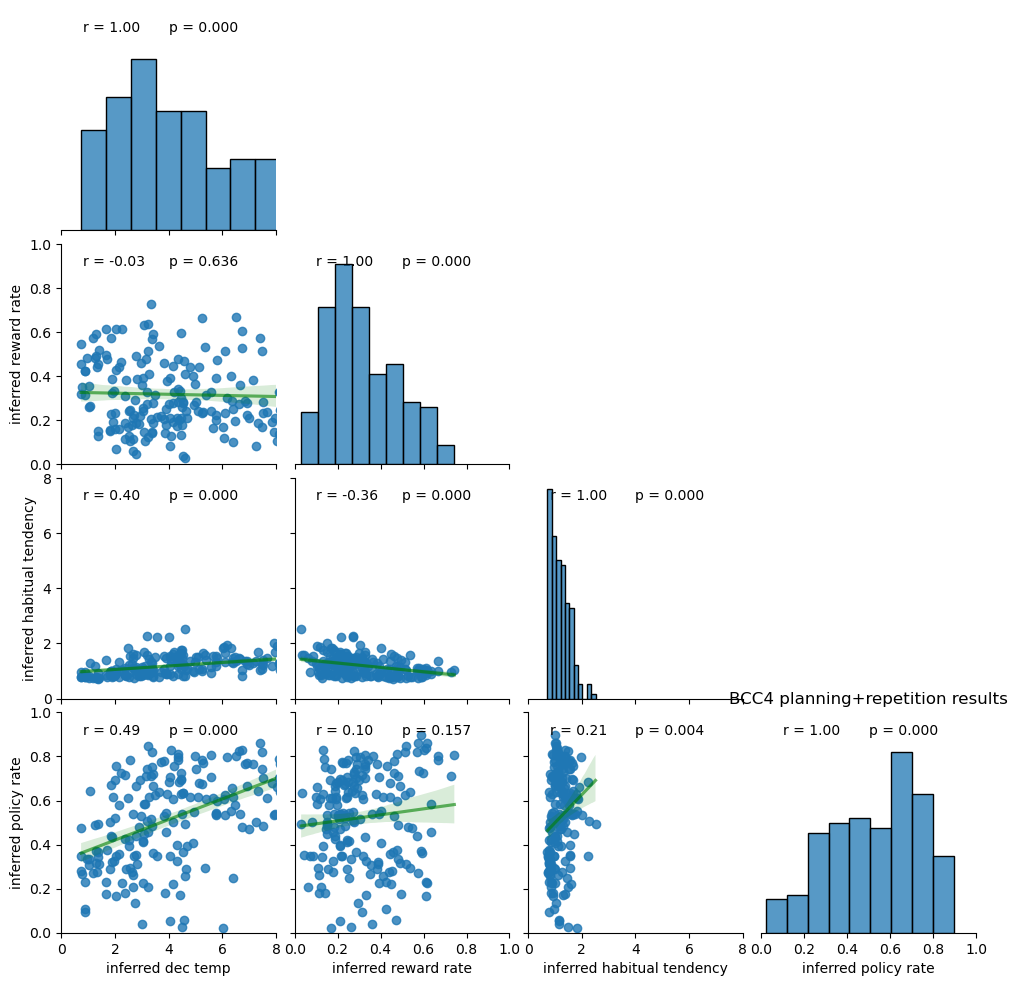

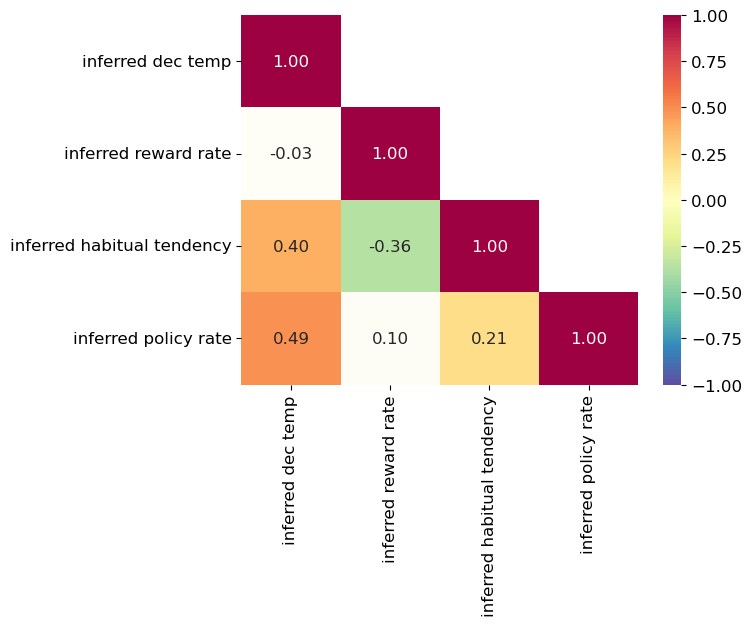

In [16]:
# BCC4 planning repetition analysis

learn_rewards = True
learn_habit = True
use_h = False
learn_cached = False

param_names = []
param_ranges = []

prefix = "BCC"
model_name = "Bayesian prior-based contextual control model"
n_pars = 0
agnt_str = ""

if learn_rewards:
    n_pars += 2
    param_names += ["dec temp", "reward rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_plan"

if learn_habit:
    # infer_h = True
    # infer_policy_rate = True 
    n_pars += 2
    agnt_str += "_habit"
    param_names += ["habitual tendency", "policy rate"]
    if use_h:
        agnt_str += "_h"
        param_ranges += [[0,1], [0,1]]
    else:
        agnt_str += "_weight"
        param_ranges += [[0,8], [0,1]]
# else:
#     infer_h = False
#     infer_policy_rate = False

if learn_cached:
    n_pars += 2
    param_names += ["cached weight", "cached rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_cached"

assert n_pars > 0, "please turn any part of the agent on, it cannot run without any learning or inference."

# choose max decision temperature for numerical stability
max_dt = 6

BCC4_p_r_param_names = param_names.copy()
BCC4_p_r_param_ranges = param_ranges.copy()

# prepare for saving results
# make base filename and folder string
agent_type = prefix+"_"+str(n_pars)+"pars"+agnt_str+"_NO_context"
print(agent_type)

# prepare for saving results
# make base filename and folder string
fname_base = agent_type+"_inference_"
print(fname_base)
# define folder where we want to save data
base_dir = os.path.join(inference_folder,fname_base[:-1])

# make directory if it doesnt exist
if fname_base[:-1] not in os.listdir(inference_folder):
    os.mkdir(base_dir)

num_steps = 600

BCC4_p_r_mean_df, BCC4_p_r_sample_df, BCC4_p_r_locs_df = load_BCC_results(learn_rewards, learn_habit, learn_cached, base_dir, global_experiment_parameters, exp_mask, fname_base, num_steps, data, param_names, use_h=False)

BCC4_p_r_agent = tu.set_up_Bayesian_inference_agent(n_agents, learn_rewards, learn_habit, learn_cached, base_dir, global_experiment_parameters, data["valid"], remove_old=False, use_h=use_h)

BCC4_p_r_params = torch.stack([torch.tensor(BCC4_p_r_mean_df["inferred "+name]) for name in BCC4_p_r_param_names], dim=-1)

# param_plot_ranges = [[-0.25,1.25], [-0.25,1.25], [0,10]]

plt.figure()
vars_of_interest = ["inferred "+name for name in param_names]
f = sns.pairplot(data=BCC4_p_r_mean_df, kind='reg', diag_kind="hist", corner=True,
                    plot_kws={'line_kws': {'color': 'green', 'alpha': 0.6}},
                    x_vars=vars_of_interest, y_vars=vars_of_interest)
f.map(tu.annot_corrfunc)
for p, p_range in enumerate(param_ranges):
    f.axes[n_pars-1,p].set_xlim(p_range)
    f.axes[p,0].set_ylim(p_range)
plt.title("BCC4 planning+repetition results")
#plt.savefig(os.path.join(base_dir, fname_str+"_pairplot_means_inferred_corr.svg"))
plt.show()

plot_correlations(BCC4_p_r_mean_df, vars_of_interest, vars_of_interest)


In [17]:
# calculate agent log likelihood using mean params

BCC4_p_r_log_like = -calculate_log_likelihood(data, BCC4_p_r_agent, BCC4_p_r_locs_df, len(BCC4_p_r_param_names), global_experiment_parameters["trials"], global_experiment_parameters["T"])

BCC4_p_r_BIC = calculate_BIC(data, BCC4_p_r_agent, BCC4_p_r_locs_df, len(BCC4_p_r_param_names), global_experiment_parameters["trials"], global_experiment_parameters["T"])

BCC4_p_r_lppd = -calculate_lppd(data, BCC4_p_r_agent, BCC4_p_r_locs_df, len(BCC4_p_r_param_names), 
                            global_experiment_parameters["trials"], global_experiment_parameters["T"], max_samples=50)

BCC4_p_r_WAIC = -calculate_waic(data, BCC4_p_r_agent, BCC4_p_r_locs_df, len(BCC4_p_r_param_names), 
                            global_experiment_parameters["trials"], global_experiment_parameters["T"], max_samples=50)

measures_df = pd.DataFrame({"subject": list(range(n_agents)), "measure": BCC4_p_r_log_like, "type": ["log likelihood"]*n_agents, "model": ["BCC4_p_r"]*n_agents})
measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": BCC4_p_r_lppd, "type": ["lppd"]*n_agents, "model": ["BCC4_p_r"]*n_agents})])
measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": BCC4_p_r_BIC, "type": ["BIC"]*n_agents, "model": ["BCC4_p_r"]*n_agents})])
measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": BCC4_p_r_WAIC, "type": ["WAIC"]*n_agents, "model": ["BCC4_p_r"]*n_agents})])

print("BCC4_p_r log like", BCC4_p_r_log_like.mean())

print("BCC4_p_r BIC", BCC4_p_r_BIC.mean())

print("BCC4_p_r lppd", BCC4_p_r_lppd.mean())

gc.collect()

torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size

8437

BCC_4pars_plan_cached_NO_context
BCC_4pars_plan_cached_NO_context_inference_
4
analyzing 188 data sets
4


<Figure size 640x480 with 0 Axes>

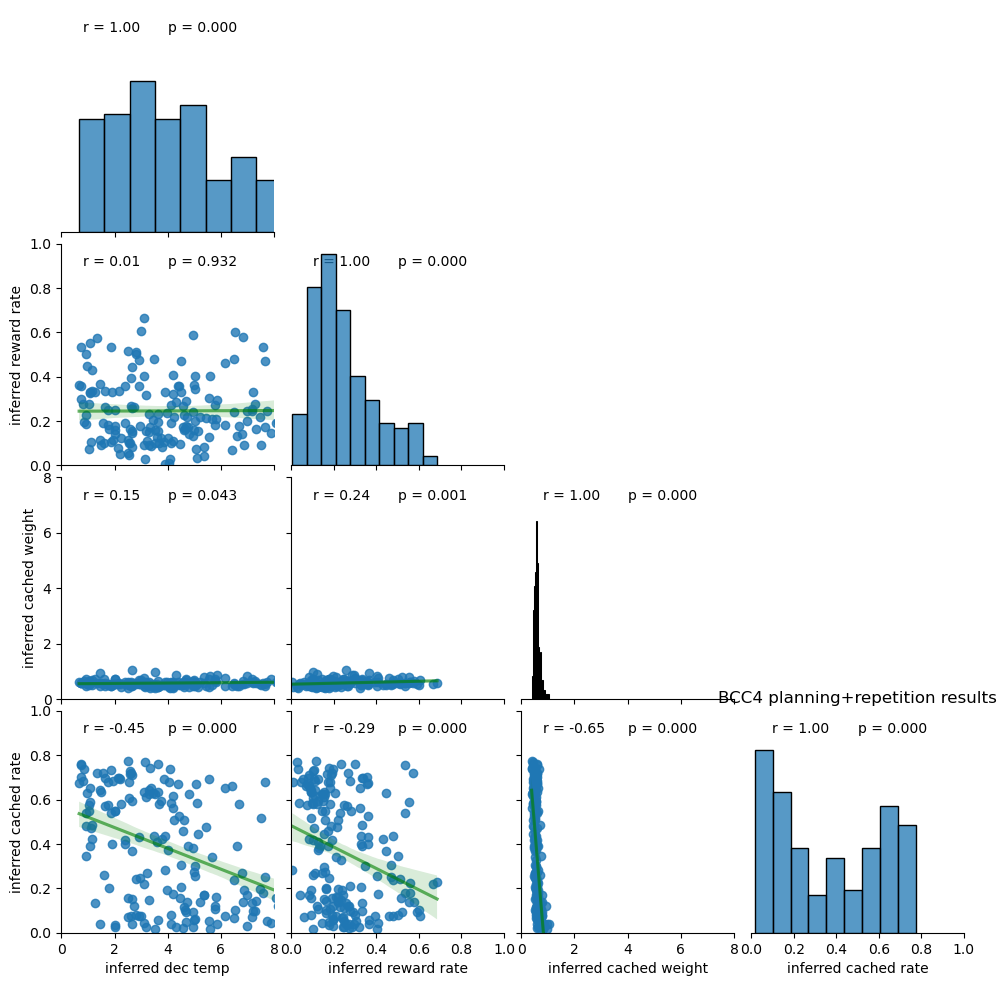

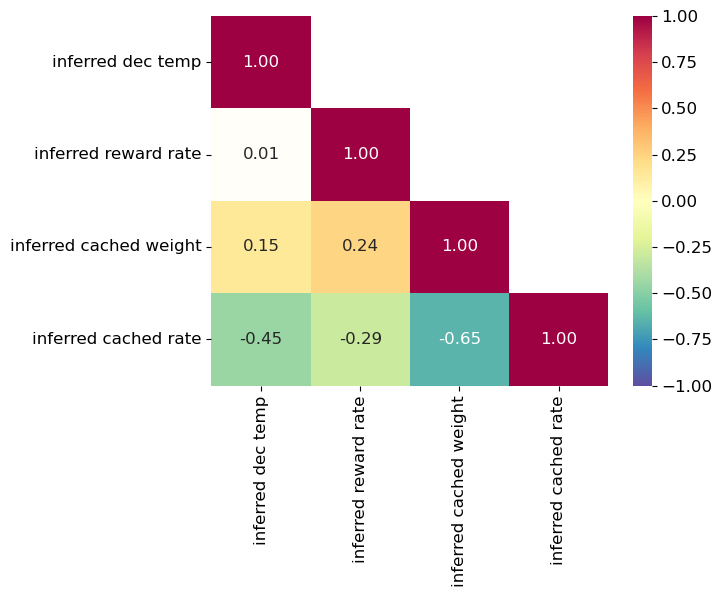

In [18]:
# BCC4 planning cached analysis

learn_rewards = True
learn_habit = False
use_h = False
learn_cached = True

param_names = []
param_ranges = []

prefix = "BCC"
model_name = "Bayesian prior-based contextual control model"
n_pars = 0
agnt_str = ""

if learn_rewards:
    n_pars += 2
    param_names += ["dec temp", "reward rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_plan"

if learn_habit:
    # infer_h = True
    # infer_policy_rate = True 
    n_pars += 2
    agnt_str += "_habit"
    param_names += ["habitual tendency", "policy rate"]
    if use_h:
        agnt_str += "_h"
        param_ranges += [[0,1], [0,1]]
    else:
        agnt_str += "_weight"
        param_ranges += [[0,8], [0,1]]
# else:
#     infer_h = False
#     infer_policy_rate = False

if learn_cached:
    n_pars += 2
    param_names += ["cached weight", "cached rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_cached"

assert n_pars > 0, "please turn any part of the agent on, it cannot run without any learning or inference."

# choose max decision temperature for numerical stability
max_dt = 6

BCC4_p_c_param_names = param_names.copy()
BCC4_p_c_param_ranges = param_ranges.copy()

# prepare for saving results
# make base filename and folder string
agent_type = prefix+"_"+str(n_pars)+"pars"+agnt_str+"_NO_context"
print(agent_type)

# prepare for saving results
# make base filename and folder string
fname_base = agent_type+"_inference_"
print(fname_base)
# define folder where we want to save data
base_dir = os.path.join(inference_folder,fname_base[:-1])

# make directory if it doesnt exist
if fname_base[:-1] not in os.listdir(inference_folder):
    os.mkdir(base_dir)

num_steps = 600

BCC4_p_c_mean_df, BCC4_p_c_sample_df, BCC4_p_c_locs_df = load_BCC_results(learn_rewards, learn_habit, learn_cached, base_dir, global_experiment_parameters, exp_mask, fname_base, num_steps, data, param_names, use_h=False)

BCC4_p_c_agent = tu.set_up_Bayesian_inference_agent(n_agents, learn_rewards, learn_habit, learn_cached, base_dir, global_experiment_parameters, data["valid"], remove_old=False, use_h=use_h)

BCC4_p_c_params = torch.stack([torch.tensor(BCC4_p_c_mean_df["inferred "+name]) for name in BCC4_p_c_param_names], dim=-1)

# param_plot_ranges = [[-0.25,1.25], [-0.25,1.25], [0,10]]

plt.figure()
vars_of_interest = ["inferred "+name for name in param_names]
f = sns.pairplot(data=BCC4_p_c_mean_df, kind='reg', diag_kind="hist", corner=True,
                    plot_kws={'line_kws': {'color': 'green', 'alpha': 0.6}},
                    x_vars=vars_of_interest, y_vars=vars_of_interest)
f.map(tu.annot_corrfunc)
for p, p_range in enumerate(param_ranges):
    f.axes[n_pars-1,p].set_xlim(p_range)
    f.axes[p,0].set_ylim(p_range)
plt.title("BCC4 planning+repetition results")
#plt.savefig(os.path.join(base_dir, fname_str+"_pairplot_means_inferred_corr.svg"))
plt.show()


plot_correlations(BCC4_p_c_mean_df, vars_of_interest, vars_of_interest)

In [19]:
# calculate agent log likelihood using mean params

BCC4_p_c_log_like = -calculate_log_likelihood(data, BCC4_p_c_agent, BCC4_p_c_locs_df, len(BCC4_p_c_param_names), global_experiment_parameters["trials"], global_experiment_parameters["T"])

BCC4_p_c_BIC = calculate_BIC(data, BCC4_p_c_agent, BCC4_p_c_locs_df, len(BCC4_p_c_param_names), global_experiment_parameters["trials"], global_experiment_parameters["T"])

BCC4_p_c_lppd = -calculate_lppd(data, BCC4_p_c_agent, BCC4_p_c_locs_df, len(BCC4_p_c_param_names), 
                            global_experiment_parameters["trials"], global_experiment_parameters["T"], max_samples=50)

BCC4_p_c_WAIC = -calculate_waic(data, BCC4_p_c_agent, BCC4_p_c_locs_df, len(BCC4_p_c_param_names), 
                            global_experiment_parameters["trials"], global_experiment_parameters["T"], max_samples=50)

measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": BCC4_p_c_log_like, "type": ["log likelihood"]*n_agents, "model": ["BCC4_p_c"]*n_agents})])
measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": BCC4_p_c_lppd, "type": ["lppd"]*n_agents, "model": ["BCC4_p_c"]*n_agents})])
measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": BCC4_p_c_BIC, "type": ["BIC"]*n_agents, "model": ["BCC4_p_c"]*n_agents})])
measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": BCC4_p_c_WAIC, "type": ["WAIC"]*n_agents, "model": ["BCC4_p_c"]*n_agents})])

print("BCC4_p_c log like", BCC4_p_c_log_like.mean())

print("BCC4_p_c BIC", BCC4_p_c_BIC.mean())

print("BCC4_p_c lppd", BCC4_p_c_lppd.mean())

gc.collect()

torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size

894

### Load BCC6results, and plot correlations between inferred parameters

BCC_6pars_plan_habit_weight_cached_NO_context
BCC_6pars_plan_habit_weight_cached_NO_context_inference_
6
analyzing 188 data sets
6


<Figure size 640x480 with 0 Axes>

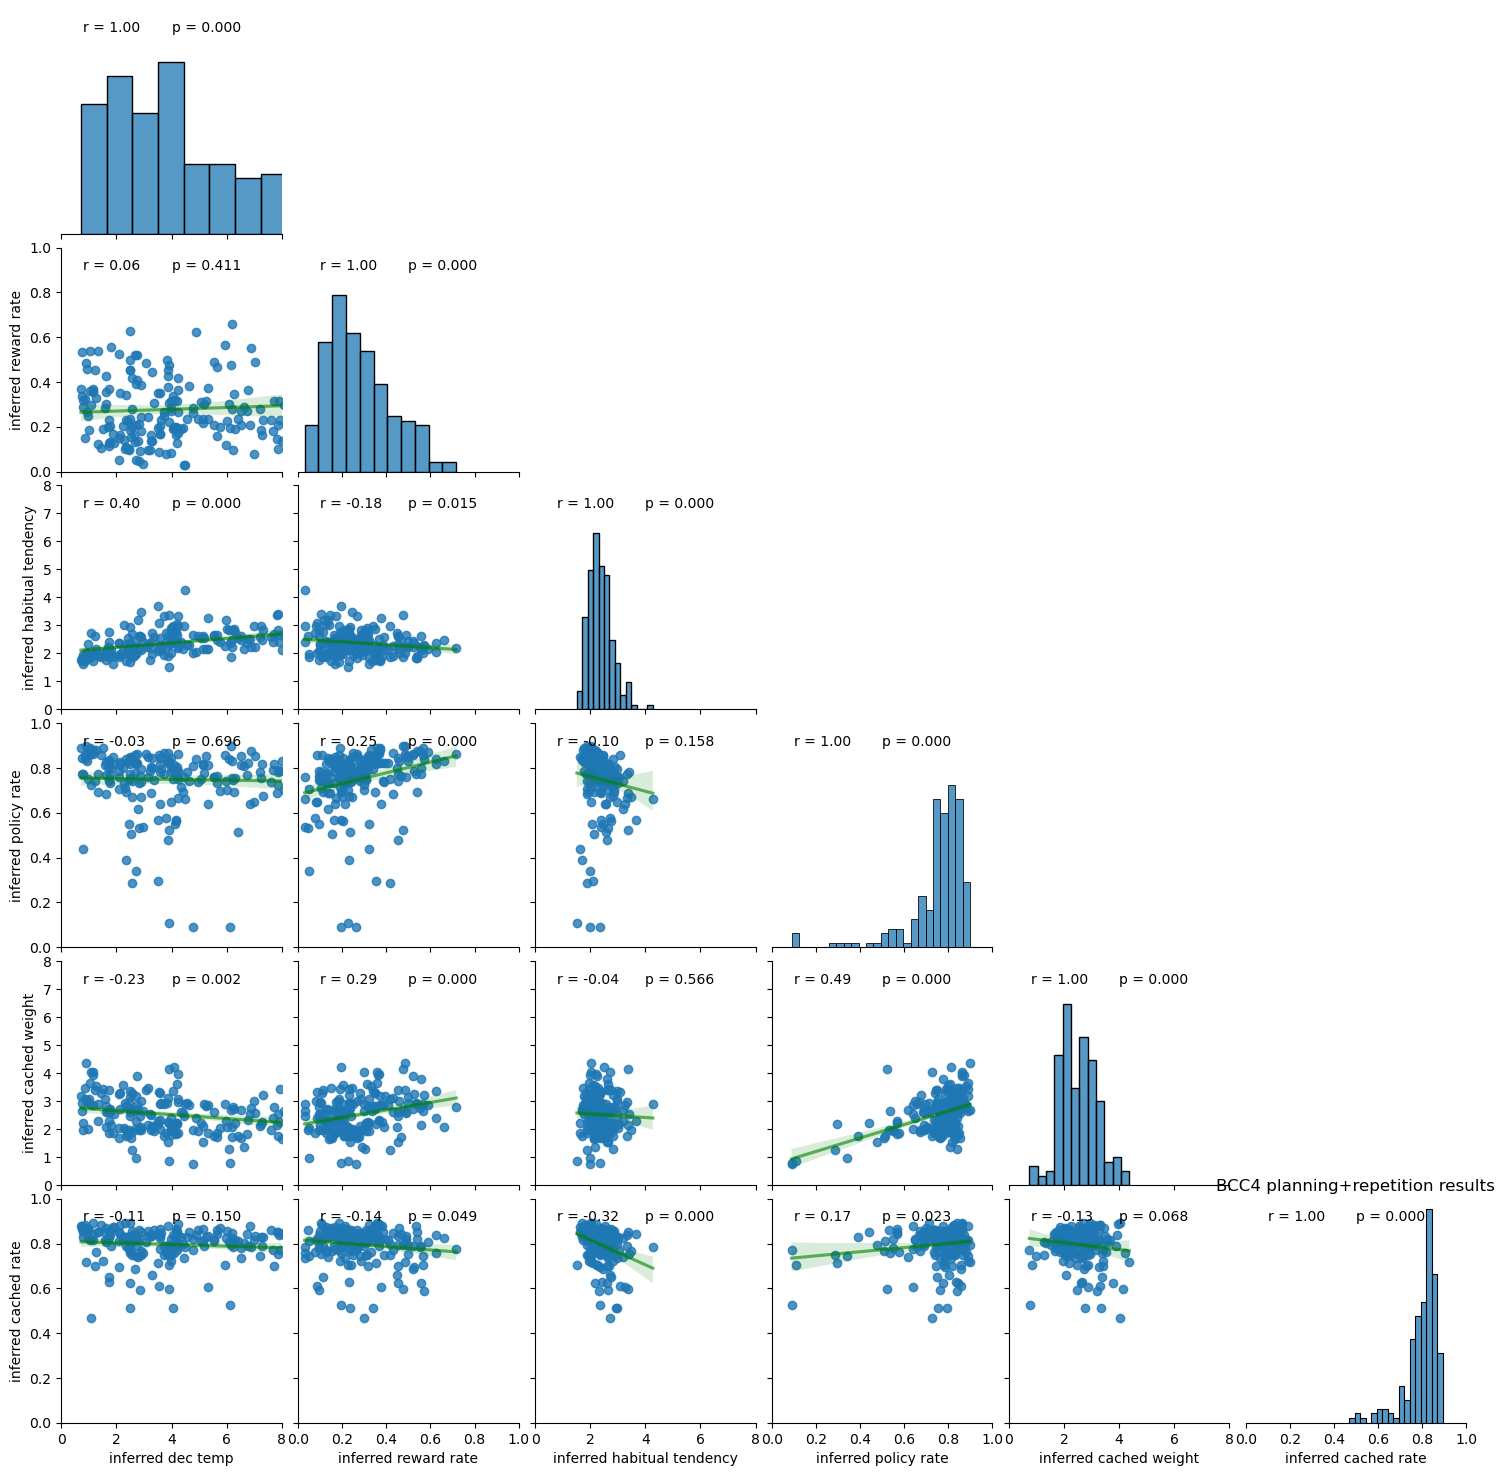

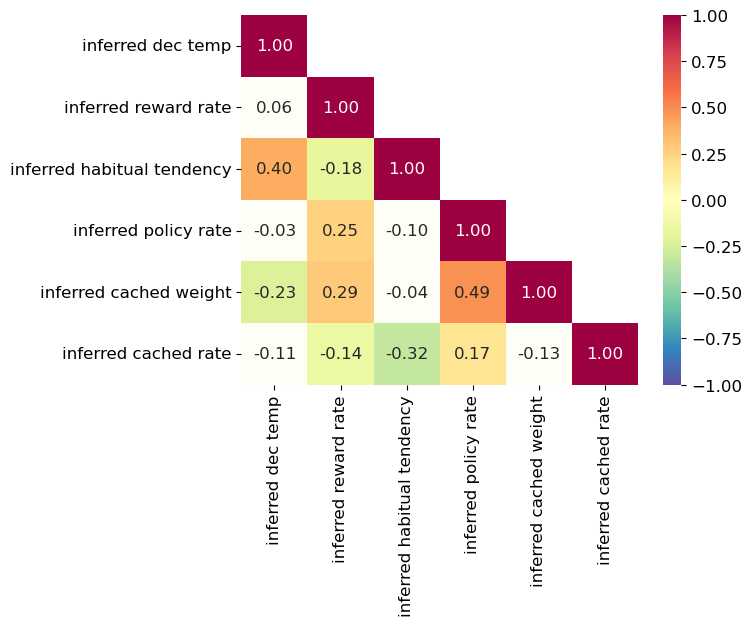

In [20]:
# BCC6 analysis

learn_rewards = True
learn_habit = True
use_h = False
learn_cached = True

param_names = []
param_ranges = []

prefix = "BCC"
model_name = "Bayesian prior-based contextual control model"
n_pars = 0
agnt_str = ""

if learn_rewards:
    n_pars += 2
    param_names += ["dec temp", "reward rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_plan"

if learn_habit:
    # infer_h = True
    # infer_policy_rate = True 
    n_pars += 2
    agnt_str += "_habit"
    param_names += ["habitual tendency", "policy rate"]
    if use_h:
        agnt_str += "_h"
        param_ranges += [[0,1], [0,1]]
    else:
        agnt_str += "_weight"
        param_ranges += [[0,8], [0,1]]
# else:
#     infer_h = False
#     infer_policy_rate = False

if learn_cached:
    n_pars += 2
    param_names += ["cached weight", "cached rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_cached"

assert n_pars > 0, "please turn any part of the agent on, it cannot run without any learning or inference."

# choose max decision temperature for numerical stability
max_dt = 6

BCC6_param_names = param_names.copy()
BCC6_param_ranges = param_ranges.copy()

# prepare for saving results
# make base filename and folder string
agent_type = prefix+"_"+str(n_pars)+"pars"+agnt_str+"_NO_context"
print(agent_type)

# prepare for saving results
# make base filename and folder string
fname_base = agent_type+"_inference_"
print(fname_base)
# define folder where we want to save data
base_dir = os.path.join(inference_folder,fname_base[:-1])

# make directory if it doesnt exist
if fname_base[:-1] not in os.listdir(inference_folder):
    os.mkdir(base_dir)

num_steps = 600

BCC6_mean_df, BCC6_sample_df, BCC6_locs_df = load_BCC_results(learn_rewards, learn_habit, learn_cached, base_dir, global_experiment_parameters, exp_mask, fname_base, num_steps, data, param_names, use_h=False)

BCC6_agent = tu.set_up_Bayesian_inference_agent(n_agents, learn_rewards, learn_habit, learn_cached, base_dir, global_experiment_parameters, data["valid"], remove_old=False, use_h=use_h)

BCC6_params = torch.stack([torch.tensor(BCC6_mean_df["inferred "+name]) for name in BCC6_param_names], dim=-1)

# param_plot_ranges = [[-0.25,1.25], [-0.25,1.25], [0,10]]

plt.figure()
vars_of_interest = ["inferred "+name for name in param_names]
f = sns.pairplot(data=BCC6_mean_df, kind='reg', diag_kind="hist", corner=True,
                    plot_kws={'line_kws': {'color': 'green', 'alpha': 0.6}},
                    x_vars=vars_of_interest, y_vars=vars_of_interest)
f.map(tu.annot_corrfunc)
for p, p_range in enumerate(param_ranges):
    f.axes[n_pars-1,p].set_xlim(p_range)
    f.axes[p,0].set_ylim(p_range)
plt.title("BCC4 planning+repetition results")
#plt.savefig(os.path.join(base_dir, fname_str+"_pairplot_means_inferred_corr.svg"))
plt.show()

plot_correlations(BCC6_mean_df, vars_of_interest, vars_of_interest)

In [21]:
# calculate agent log likelihood using mean params

BCC6_log_like = -calculate_log_likelihood(data, BCC6_agent, BCC6_locs_df, len(BCC6_param_names), global_experiment_parameters["trials"], global_experiment_parameters["T"])

BCC6_BIC = calculate_BIC(data, BCC6_agent, BCC6_locs_df, len(BCC6_param_names), global_experiment_parameters["trials"], global_experiment_parameters["T"])

BCC6_lppd = -calculate_lppd(data, BCC6_agent, BCC6_locs_df, len(BCC6_param_names), 
                            global_experiment_parameters["trials"], global_experiment_parameters["T"], max_samples=50)

BCC6_WAIC = -calculate_waic(data, BCC6_agent, BCC6_locs_df, len(BCC6_param_names), 
                            global_experiment_parameters["trials"], global_experiment_parameters["T"], max_samples=50)

measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": BCC6_log_like, "type": ["log likelihood"]*n_agents, "model": ["BCC6"]*n_agents})])
measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": BCC6_lppd, "type": ["lppd"]*n_agents, "model": ["BCC6"]*n_agents})])
measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": BCC6_BIC, "type": ["BIC"]*n_agents, "model": ["BCC6"]*n_agents})])
measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": BCC6_WAIC, "type": ["WAIC"]*n_agents, "model": ["BCC6"]*n_agents})])

print("BCC6 log like", BCC6_log_like.mean())

print("BCC6 BIC", BCC6_BIC.mean())

print("BCC6 lppd", BCC6_lppd.mean())

gc.collect()

torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size

44615

In [22]:
print(measures_df)

     subject     measure            type     model
0          0  177.629669  log likelihood  BCC4_p_r
1          1  167.126801  log likelihood  BCC4_p_r
2          2  255.577637  log likelihood  BCC4_p_r
3          3  190.769989  log likelihood  BCC4_p_r
4          4  227.715836  log likelihood  BCC4_p_r
..       ...         ...             ...       ...
183      183  521.404785            WAIC      BCC6
184      184  467.580048            WAIC      BCC6
185      185  364.804626            WAIC      BCC6
186      186  426.375366            WAIC      BCC6
187      187  505.034668            WAIC      BCC6

[2256 rows x 4 columns]


/home/sarah/anaconda3/envs/two_stage/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/sarah/anaconda3/envs/two_stage/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/sarah/anaconda3/envs/two_stage/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/hom

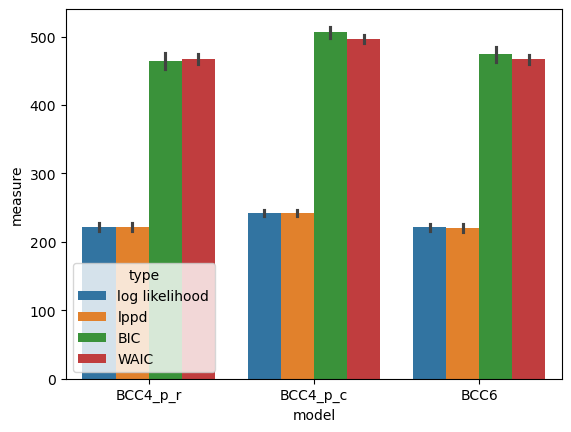

In [23]:
# plot differences in fit for BCC model

plt.figure()
sns.barplot(data=measures_df, x="model", y="measure", hue="type")
plt.show()

### Load MFMB4 results, and plot correlations between inferred parameters

mbmf__inference_
analyzing 188 data sets


<Figure size 640x480 with 0 Axes>

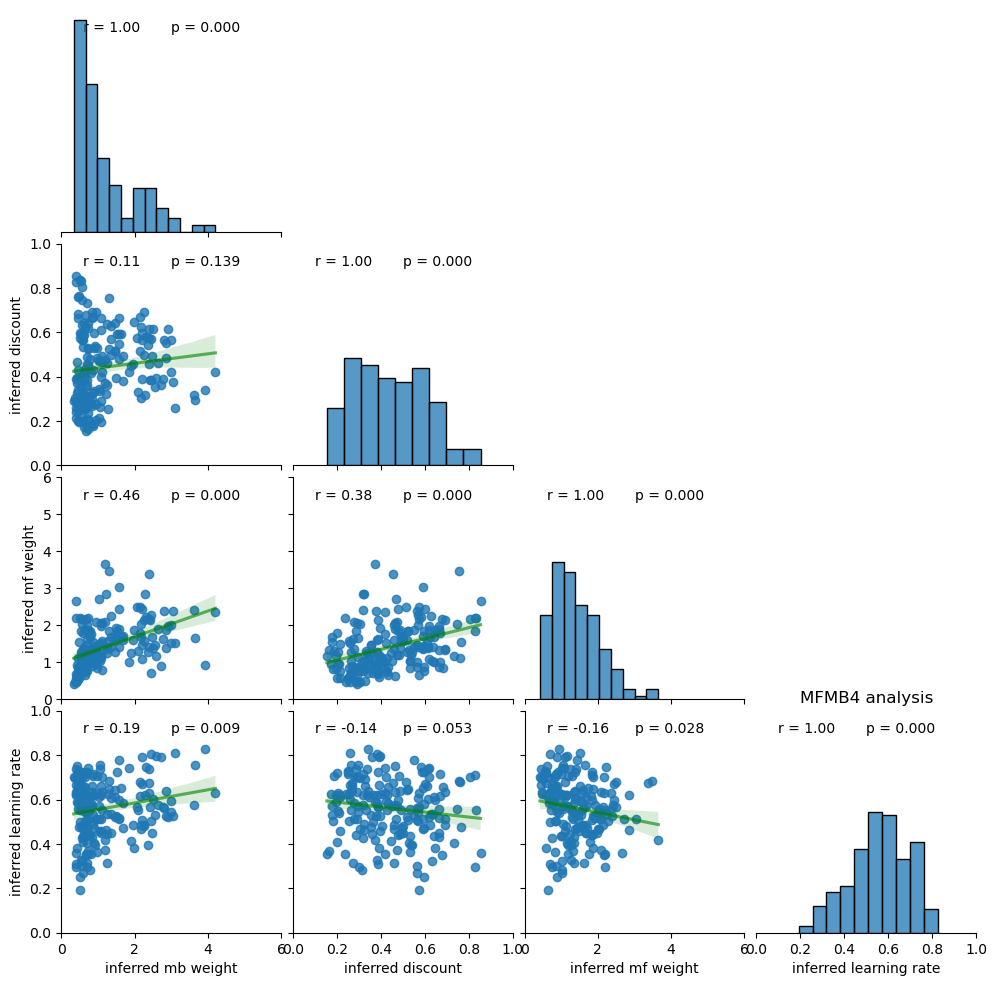

This is inference for the twostage task using the two beta mbmf model(mbmf_) with 188 agents.
The settings are: use p False


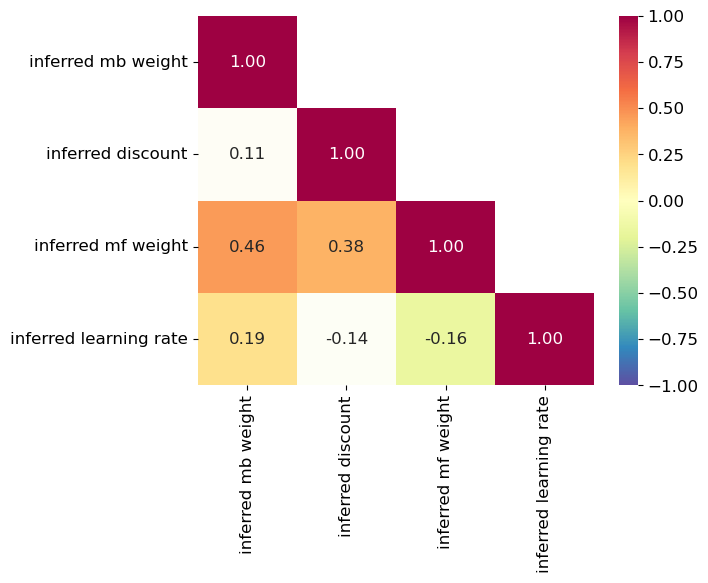

In [24]:
# MFMB4 analysis

# set parameters and their names
learn_prior = False

use_orig = False

use_p = False
restrict_alpha = False
max_dt = 6

n_pars = 4

agnt_str = ""

if use_orig:
    agnt_str += "mbmfOrig_"
    param_names = ["discount", "learning rate", "dec temp", "weight"]
    model_name = "original original w and beta model"
    param_ranges = [[0,1], [0,1], [0,8], [0,1]]
else:
    agnt_str += "mbmf_"
    param_names = ["mb weight", "discount", "mf weight", "learning rate"]
    model_name = "two beta mbmf model"
    param_ranges = [[0,max_dt], [0,1], [0,max_dt], [0,1]]


if learn_prior:
    n_pars += 2
    param_names += ["prior lr", "prior weight"]
    param_ranges += [[0,1], [0,max_dt]]
    agnt_str += "_prior"

if use_p:
    n_pars += 1
    agnt_str += "_p"
    param_names += ["repetition"]
    
if restrict_alpha:
    agnt_str += "_resticted"
    min_alpha = 0.1
else:
    min_alpha = 0

# prepare for saving results
# make base filename and folder string
agent_type = agnt_str

MFMB4_param_names = param_names.copy()
MFMB4_param_ranges = param_ranges.copy()

# prepare for saving results
# make base filename and folder string
fname_base = agent_type+"_inference_"
print(fname_base)
# define folder where we want to save data
base_dir = os.path.join(inference_folder,fname_base[:-1])

# make directory if it doesnt exist
if fname_base[:-1] not in os.listdir(inference_folder):
    os.mkdir(base_dir)

num_steps = 600

MFMB4_mean_df, MFMB4_sample_df, MFMB4_locs_df = load_MFMB_results(use_orig, learn_prior, use_p, restrict_alpha, max_dt, base_dir, global_experiment_parameters, data["valid"], fname_base, num_steps, data, MFMB4_param_names)

MFMB4_agent = tu.set_up_mbmf_inference_agent(n_agents, learn_prior, use_orig, use_p, restrict_alpha, max_dt, min_alpha, base_dir, global_experiment_parameters, data["valid"], remove_old=False)

MFMB4_params = torch.stack([torch.tensor(MFMB4_mean_df["inferred "+name]) for name in MFMB4_param_names], dim=-1)

plt.figure()
vars_of_interest = ["inferred "+name for name in MFMB4_param_names]
f = sns.pairplot(data=MFMB4_mean_df, kind='reg', diag_kind="hist", corner=True,
                    plot_kws={'line_kws': {'color': 'green', 'alpha': 0.6}},
                    x_vars=vars_of_interest, y_vars=vars_of_interest)
f.map(tu.annot_corrfunc)
for p, p_range in enumerate(MFMB4_param_ranges):
    f.axes[n_pars-1,p].set_xlim(p_range)
    f.axes[p,0].set_ylim(p_range)
plt.title("MFMB4 analysis")
#plt.savefig(os.path.join(base_dir, fname_str+"_pairplot_means_inferred_corr.svg"))
plt.show()
        
print("This is inference for the twostage task using the "+model_name+"("+agent_type+")"+" with "+str(n_agents)+" agents.")
print("The settings are: use p", use_p)

plot_correlations(MFMB4_mean_df, vars_of_interest, vars_of_interest)

In [25]:
# calculate agent log likelihood using mean params

MFMB4_log_like = -calculate_log_likelihood(data, MFMB4_agent, MFMB4_locs_df, len(MFMB4_param_names), global_experiment_parameters["trials"], global_experiment_parameters["T"])

MFMB4_BIC = calculate_BIC(data, MFMB4_agent, MFMB4_locs_df, len(MFMB4_param_names), global_experiment_parameters["trials"], global_experiment_parameters["T"])

MFMB4_lppd = -calculate_lppd(data, MFMB4_agent, MFMB4_locs_df, len(MFMB4_param_names), 
                            global_experiment_parameters["trials"], global_experiment_parameters["T"], max_samples=50)

MFMB4_WAIC = -calculate_waic(data, MFMB4_agent, MFMB4_locs_df, len(MFMB4_param_names), 
                            global_experiment_parameters["trials"], global_experiment_parameters["T"], max_samples=50)

measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": MFMB4_log_like, "type": ["log likelihood"]*n_agents, "model": ["MFMB4"]*n_agents})])
measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": MFMB4_lppd, "type": ["lppd"]*n_agents, "model": ["MFMB4"]*n_agents})])
measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": MFMB4_BIC, "type": ["BIC"]*n_agents, "model": ["MFMB4"]*n_agents})])
measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": MFMB4_WAIC, "type": ["WAIC"]*n_agents, "model": ["MFMB4"]*n_agents})])

print("MFMB4 log like", MFMB4_log_like.mean())

print("MFMB4 BIC", MFMB4_BIC.mean())

gc.collect()

torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size

93956

/home/sarah/anaconda3/envs/two_stage/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/sarah/anaconda3/envs/two_stage/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/sarah/anaconda3/envs/two_stage/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/hom

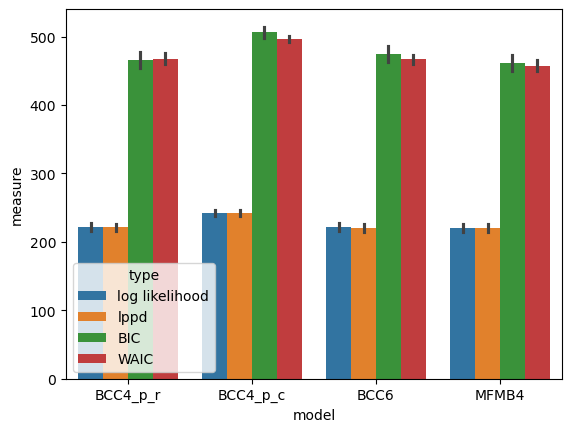

In [26]:
plt.figure()
sns.barplot(data=measures_df, x="model", y="measure", hue="type")
plt.show()

### Load MFMB6 results, and plot correlations between inferred parameters

mbmf__prior_inference_
analyzing 188 data sets


<Figure size 640x480 with 0 Axes>

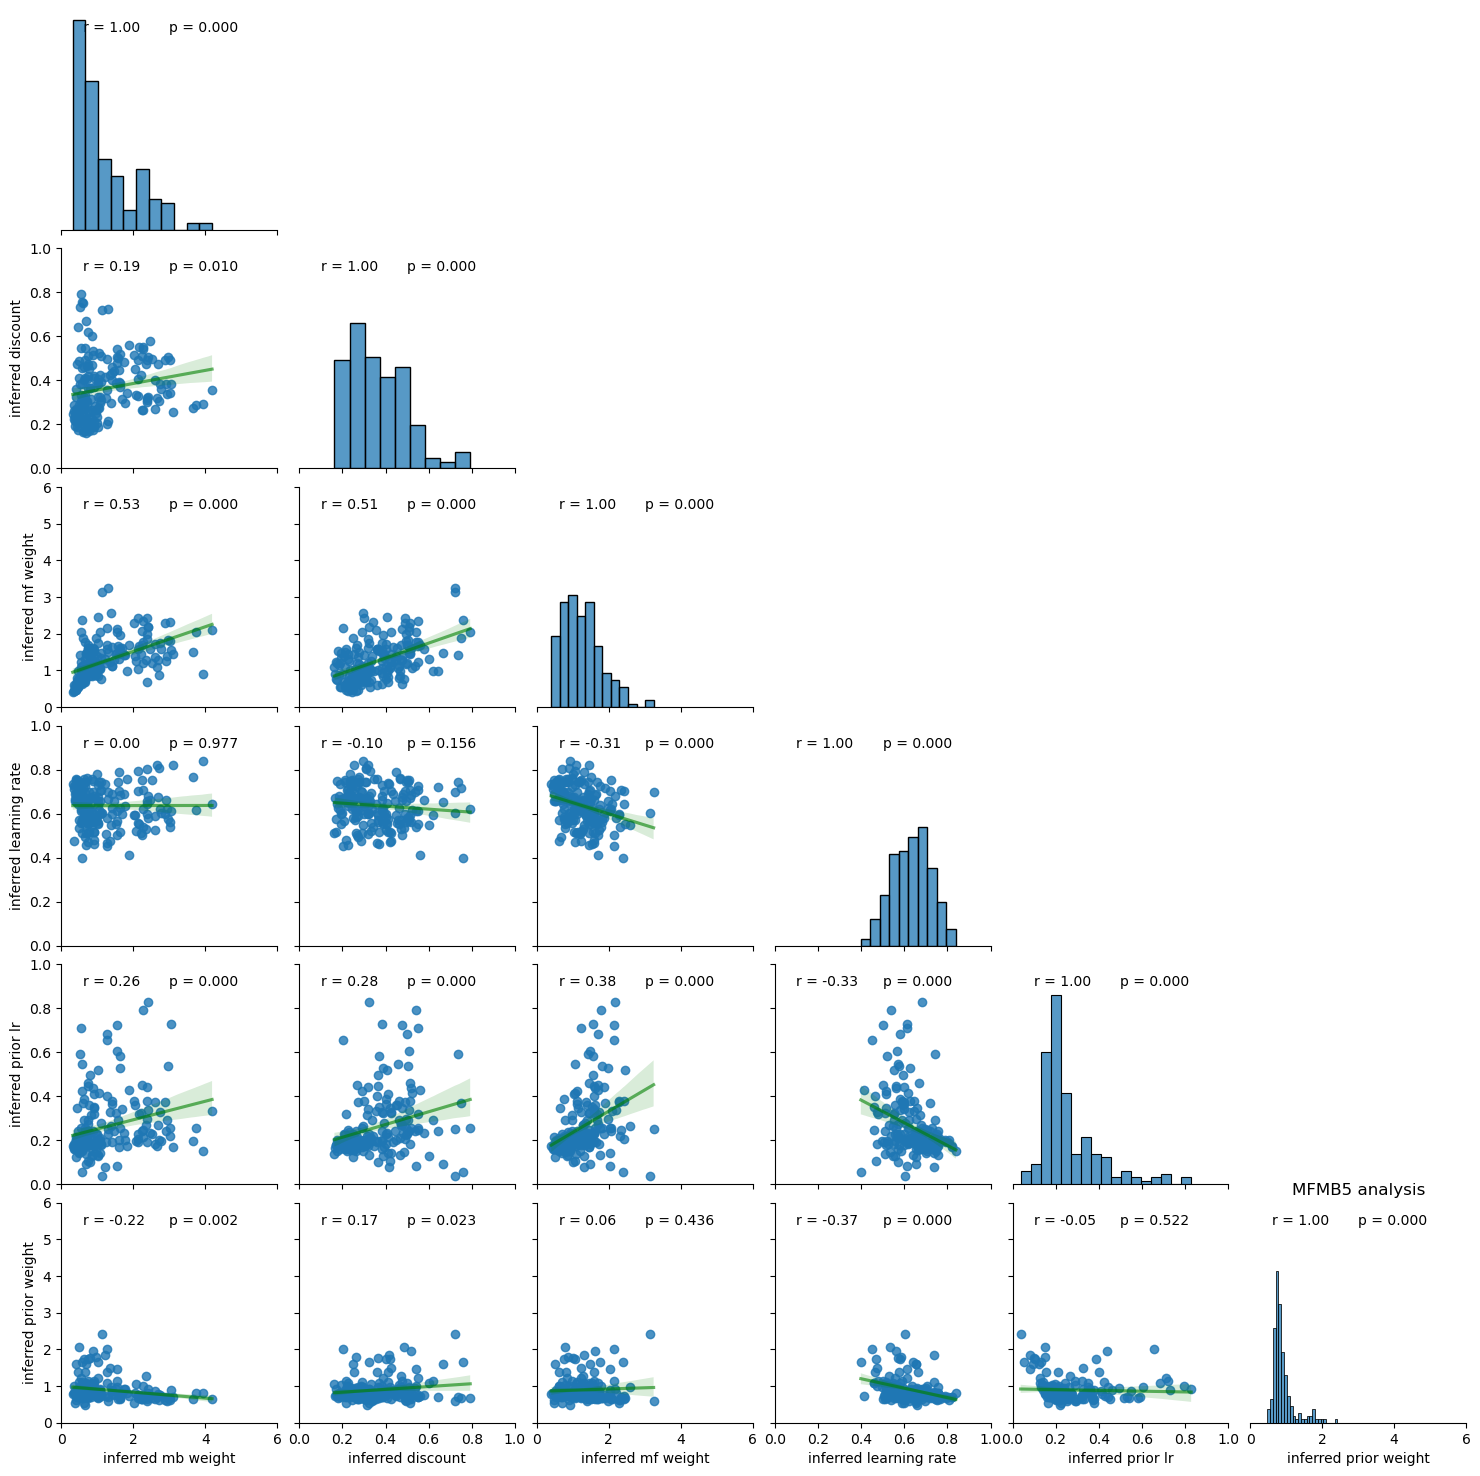

This is inference for the twostage task using the two beta mbmf model(mbmf__prior) with 188 agents.
The settings are: use p False


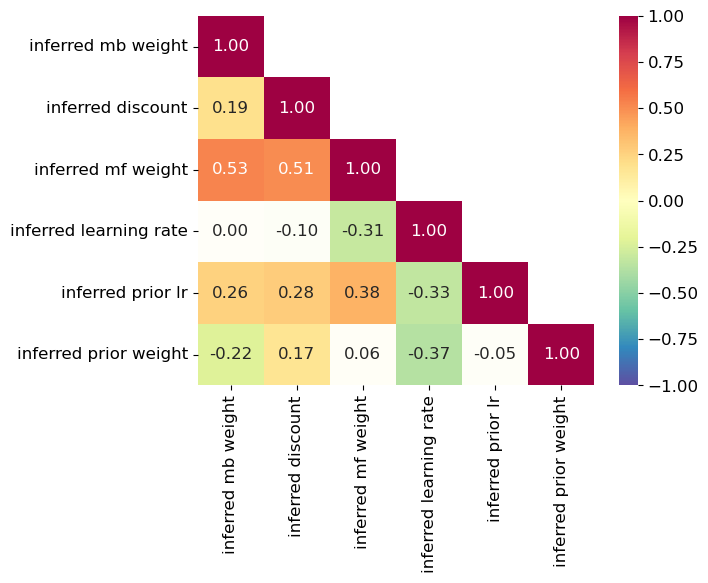

In [27]:
# MFMB6 analysis

# set parameters and their names
learn_prior = True

use_orig = False

use_p = False
restrict_alpha = False
max_dt = 6

n_pars = 4

agnt_str = ""

if use_orig:
    agnt_str += "mbmfOrig_"
    param_names = ["discount", "learning rate", "dec temp", "weight"]
    model_name = "original original w and beta model"
    param_ranges = [[0,1], [0,1], [0,8], [0,1]]
else:
    agnt_str += "mbmf_"
    param_names = ["mb weight", "discount", "mf weight", "learning rate"]
    model_name = "two beta mbmf model"
    param_ranges = [[0,max_dt], [0,1], [0,max_dt], [0,1]]


if learn_prior:
    n_pars += 2
    param_names += ["prior lr", "prior weight"]
    param_ranges += [[0,1], [0,max_dt]]
    agnt_str += "_prior"

if use_p:
    n_pars += 1
    agnt_str += "_p"
    param_names += ["repetition"]
    
if restrict_alpha:
    agnt_str += "_resticted"
    min_alpha = 0.1
else:
    min_alpha = 0

# prepare for saving results
# make base filename and folder string
agent_type = agnt_str

MFMB6_param_names = param_names.copy()
MFMB6_param_ranges = param_ranges.copy()

# prepare for saving results
# make base filename and folder string
fname_base = agent_type+"_inference_"
print(fname_base)
# define folder where we want to save data
base_dir = os.path.join(inference_folder,fname_base[:-1])

# make directory if it doesnt exist
if fname_base[:-1] not in os.listdir(inference_folder):
    os.mkdir(base_dir)

num_steps = 600

MFMB6_mean_df, MFMB6_sample_df, MFMB6_locs_df = load_MFMB_results(use_orig, learn_prior, use_p, restrict_alpha, max_dt, base_dir, global_experiment_parameters, data["valid"], fname_base, num_steps, data, MFMB6_param_names)

MFMB6_agent = tu.set_up_mbmf_inference_agent(n_agents, learn_prior, use_orig, use_p, restrict_alpha, max_dt, min_alpha, base_dir, global_experiment_parameters, data["valid"], remove_old=False)

MFMB6_params = torch.stack([torch.tensor(MFMB6_mean_df["inferred "+name]) for name in MFMB6_param_names], dim=-1)

plt.figure()
vars_of_interest = ["inferred "+name for name in MFMB6_param_names]
f = sns.pairplot(data=MFMB6_mean_df, kind='reg', diag_kind="hist", corner=True,
                    plot_kws={'line_kws': {'color': 'green', 'alpha': 0.6}},
                    x_vars=vars_of_interest, y_vars=vars_of_interest)
f.map(tu.annot_corrfunc)
for p, p_range in enumerate(MFMB6_param_ranges):
    f.axes[n_pars-1,p].set_xlim(p_range)
    f.axes[p,0].set_ylim(p_range)
plt.title("MFMB5 analysis")
#plt.savefig(os.path.join(base_dir, fname_str+"_pairplot_means_inferred_corr.svg"))
plt.show()
        
print("This is inference for the twostage task using the "+model_name+"("+agent_type+")"+" with "+str(n_agents)+" agents.")
print("The settings are: use p", use_p)

plot_correlations(MFMB6_mean_df, vars_of_interest, vars_of_interest)

In [28]:
# calculate agent log likelihood using mean params

MFMB6_log_like = -calculate_log_likelihood(data, MFMB6_agent, MFMB6_locs_df, len(MFMB6_param_names), global_experiment_parameters["trials"], global_experiment_parameters["T"])

MFMB6_BIC = calculate_BIC(data, MFMB6_agent, MFMB6_locs_df, len(MFMB6_param_names), global_experiment_parameters["trials"], global_experiment_parameters["T"])

MFMB6_lppd = -calculate_lppd(data, MFMB6_agent, MFMB6_locs_df, len(MFMB6_param_names), 
                            global_experiment_parameters["trials"], global_experiment_parameters["T"], max_samples=50)

MFMB6_WAIC = -calculate_waic(data, MFMB6_agent, MFMB6_locs_df, len(MFMB6_param_names), 
                            global_experiment_parameters["trials"], global_experiment_parameters["T"], max_samples=50)

measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": MFMB6_log_like, "type": ["log likelihood"]*n_agents, "model": ["MFMB6"]*n_agents})])
measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": MFMB6_lppd, "type": ["lppd"]*n_agents, "model": ["MFMB6"]*n_agents})])
measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": MFMB6_BIC, "type": ["BIC"]*n_agents, "model": ["MFMB6"]*n_agents})])
measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": MFMB6_WAIC, "type": ["WAIC"]*n_agents, "model": ["MFMB6"]*n_agents})])

print("MFMB6 log like", MFMB6_log_like.mean())

print("MFMB6 BIC", MFMB6_BIC.mean())

gc.collect()

torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size([188])
torch.Size

48103

/home/sarah/anaconda3/envs/two_stage/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/sarah/anaconda3/envs/two_stage/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/sarah/anaconda3/envs/two_stage/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/hom

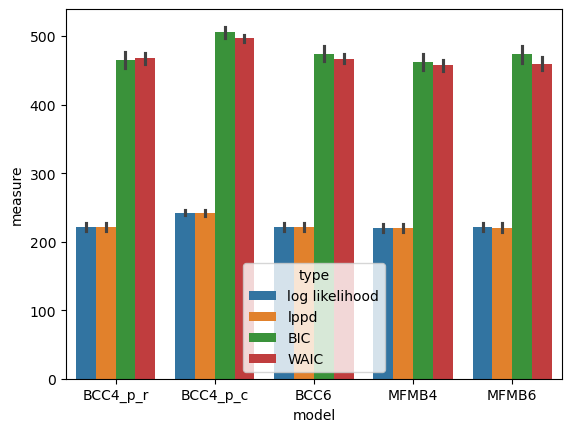

In [29]:
plt.figure()
sns.barplot(data=measures_df, x="model", y="measure", hue="type")
plt.savefig(os.path.join(model_comp_folder, "model_comparison.svg"))
plt.savefig(os.path.join(model_comp_folder, "model_comparison.png"))
plt.show()

In [27]:
with open(non_fit_file, "r") as f:
    all_didnt_fit = json.load(f)

did_fit = torch.ones(n_agents).bool()
did_fit[all_didnt_fit] = False

print(did_fit.sum())

tensor(165)


In [28]:
all_total_log_likes = torch.stack([BCC3_log_like, BCC4_log_like, MFMB4_log_like, MFMB5_log_like], dim=-1)

winning_model = all_total_log_likes.argmin(dim=-1)

print("BCC3 wins", (winning_model==0).sum())
print("BCC4 wins", (winning_model==1).sum())
print("MFMB4 wins", (winning_model==2).sum())
print("MFMB5 wins", (winning_model==3).sum())

all_log_likes_exc_prob, all_log_likes_avg_best_model = calculate_exceedance_prob(-all_total_log_likes)

BCC3 wins tensor(21)
BCC4 wins tensor(53)
MFMB4 wins tensor(28)
MFMB5 wins tensor(86)
p model mean according to measure tensor([0.1310, 0.2563, 0.1553, 0.4574])
best model: tensor(3) exceedance prob tensor(1.)
is significantly different from uniform? TtestResult(statistic=128.20754717564446, pvalue=0.0, df=499)


In [29]:
all_total_log_likes_did_fit = torch.stack([BCC3_log_like, BCC4_log_like, MFMB4_log_like, MFMB5_log_like], dim=-1)[did_fit]

winning_model = all_total_log_likes_did_fit.argmin(dim=-1)

print("BCC3 wins", (winning_model==0).sum())
print("BCC4 wins", (winning_model==1).sum())
print("MFMB4 wins", (winning_model==2).sum())
print("MFMB5 wins", (winning_model==3).sum())

all_log_likes_exc_prob_did_fit, all_log_likes_avg_best_model_did_fit = calculate_exceedance_prob(-all_total_log_likes_did_fit)

BCC3 wins tensor(21)
BCC4 wins tensor(35)
MFMB4 wins tensor(25)
MFMB5 wins tensor(84)
p model mean according to measure tensor([0.1393, 0.2081, 0.1516, 0.5009])
best model: tensor(3) exceedance prob tensor(1.)
is significantly different from uniform? TtestResult(statistic=147.26753261819698, pvalue=0.0, df=499)


In [30]:
BCC4_MFMB4_total_log_likes = torch.stack([BCC4_log_like, MFMB4_log_like], dim=-1)

winning_model = BCC4_MFMB4_total_log_likes.argmin(dim=-1)

print("BCC4 wins", (winning_model==0).sum())
print("MFMB4 wins", (winning_model==1).sum())

BCC4_MFMB4_log_likes_exc_prob, BCC4_MFMB4_total_log_likes_avg_best_model = calculate_exceedance_prob(-BCC4_MFMB4_total_log_likes)

BCC4 wins tensor(84)
MFMB4 wins tensor(104)
p model mean according to measure tensor([0.4321, 0.5679])
best model: tensor(1) exceedance prob tensor(0.9760)
is significantly different from uniform? TtestResult(statistic=43.485335051674426, pvalue=3.7088533226898525e-172, df=499)


In [31]:
BCC4_MFMB4_total_log_likes_did_fit = torch.stack([BCC4_log_like, MFMB4_log_like], dim=-1)[did_fit]

winning_model = BCC4_MFMB4_total_log_likes_did_fit.argmin(dim=-1)

print("BCC4 wins", (winning_model==0).sum())
print("MFMB4 wins", (winning_model==1).sum())

BCC4_MFMB4_log_likes_exc_prob_did_fit, BCC4_MFMB4_total_log_likes_avg_best_model_did_fit = calculate_exceedance_prob(-BCC4_MFMB4_total_log_likes_did_fit)

BCC4 wins tensor(65)
MFMB4 wins tensor(100)
p model mean according to measure tensor([0.3904, 0.6096])
best model: tensor(1) exceedance prob tensor(1.)
is significantly different from uniform? TtestResult(statistic=67.77020133268103, pvalue=3.851488299293492e-254, df=499)


In [32]:
BCC4_MFMB5_total_log_likes = torch.stack([BCC4_log_like, MFMB5_log_like], dim=-1)

winning_model = BCC4_MFMB5_total_log_likes.argmin(dim=-1)

print("BCC4 wins", (winning_model==0).sum())
print("MFMB5 wins", (winning_model==1).sum())

BCC4_MFMB5_log_likes_exc_prob, BCC4_MFMB5_total_log_likes_avg_best_model = calculate_exceedance_prob(-BCC4_MFMB5_total_log_likes)

BCC4 wins tensor(76)
MFMB5 wins tensor(112)
p model mean according to measure tensor([0.3972, 0.6028])
best model: tensor(1) exceedance prob tensor(0.9940)
is significantly different from uniform? TtestResult(statistic=65.78298912456529, pvalue=2.439343281706144e-248, df=499)


In [33]:
BCC4_MFMB5_total_log_likes_did_fit = torch.stack([BCC4_log_like, MFMB5_log_like], dim=-1)[did_fit]

winning_model = BCC4_MFMB5_total_log_likes_did_fit.argmin(dim=-1)

print("BCC4 wins", (winning_model==0).sum())
print("MFMB4 wins", (winning_model==1).sum())

BCC4_MFMB5_log_likes_exc_prob_did_fit, BCC4_MFMB5_total_log_likes_avg_best_model_did_fit = calculate_exceedance_prob(-BCC4_MFMB5_total_log_likes_did_fit)

BCC4 wins tensor(58)
MFMB4 wins tensor(107)
p model mean according to measure tensor([0.3472, 0.6528])
best model: tensor(1) exceedance prob tensor(1.)
is significantly different from uniform? TtestResult(statistic=95.88897605232273, pvalue=1e-323, df=499)


In [34]:
BCC4_MFMB4_MFMB5_total_log_likes = torch.stack([BCC4_log_like, MFMB4_log_like, MFMB5_log_like], dim=-1)

winning_model = BCC4_MFMB4_MFMB5_total_log_likes.argmin(dim=-1)

print("BCC4 wins", (winning_model==0).sum())
print("MFMB4 wins", (winning_model==1).sum())
print("MFMB5 wins", (winning_model==2).sum())

BCC4_MFMB4_MFMB5_log_likes_exc_prob, BCC4_MFMB4_MFMB5_total_log_likes_avg_best_model = calculate_exceedance_prob(-BCC4_MFMB4_MFMB5_total_log_likes)

BCC4 wins tensor(74)
MFMB4 wins tensor(28)
MFMB5 wins tensor(86)
p model mean according to measure tensor([0.3640, 0.1637, 0.4724])
best model: tensor(2) exceedance prob tensor(0.9560)
is significantly different from uniform? TtestResult(statistic=85.81912418332578, pvalue=3.019426136333391e-301, df=499)


In [35]:
BCC4_MFMB4_MFMB5_total_log_likes_did_fit = torch.stack([BCC4_log_like, MFMB4_log_like, MFMB5_log_like], dim=-1)[did_fit]

winning_model = BCC4_MFMB4_MFMB5_total_log_likes_did_fit.argmin(dim=-1)

print("BCC4 wins", (winning_model==0).sum())
print("MFMB4 wins", (winning_model==1).sum())
print("MFMB5 wins", (winning_model==2).sum())

BCC4_MFMB4_MFMB5_log_likes_exc_prob_did_fit, BCC4_MFMB4_MFMB5_total_log_likes_avg_best_model_did_fit = calculate_exceedance_prob(-BCC4_MFMB4_MFMB5_total_log_likes_did_fit)

print((winning_model==0).sum()/n_agents)

BCC4 wins tensor(56)
MFMB4 wins tensor(25)
MFMB5 wins tensor(84)
p model mean according to measure tensor([0.3240, 0.1592, 0.5168])
best model: tensor(2) exceedance prob tensor(0.9980)
is significantly different from uniform? TtestResult(statistic=111.89813488729799, pvalue=0.0, df=499)
tensor(0.2979)


In [36]:
all_total_WAICs = torch.stack([BCC3_WAIC, BCC4_WAIC, MFMB4_WAIC, MFMB5_WAIC], dim=-1)

winning_model = all_total_WAICs.argmin(dim=-1)

print("BCC3 wins", (winning_model==0).sum())
print("BCC4 wins", (winning_model==1).sum())
print("MFMB4 wins", (winning_model==2).sum())
print("MFMB5 wins", (winning_model==3).sum())

p_model = torch.nn.functional.softmax(-2*all_total_WAICs, dim=-1)
print(p_model.shape)

print(p_model.mean(dim=0))

p_model_total = torch.nn.functional.softmax(-2*all_total_WAICs.sum(dim=0), dim=-1)

print(p_model_total)

all_WAICs_exc_prob, all_WAICs_avg_best_model = calculate_exceedance_prob(-2*all_total_WAICs)

BCC3 wins tensor(16)
BCC4 wins tensor(81)
MFMB4 wins tensor(41)
MFMB5 wins tensor(50)
torch.Size([188, 4])
tensor([0.0912, 0.4237, 0.2106, 0.2746])
tensor([0., 0., 0., 1.])
p model mean according to measure tensor([0.0912, 0.4237, 0.2106, 0.2746])
best model: tensor(1) exceedance prob tensor(0.9920)
is significantly different from uniform? TtestResult(statistic=105.8025346077303, pvalue=0.0, df=499)


In [37]:
all_total_WAICs_did_fit = torch.stack([BCC3_WAIC, BCC4_WAIC, MFMB4_WAIC, MFMB5_WAIC], dim=-1)[did_fit]

winning_model = all_total_WAICs_did_fit.argmin(dim=-1)

print("BCC3 wins", (winning_model==0).sum())
print("BCC4 wins", (winning_model==1).sum())
print("MFMB4 wins", (winning_model==2).sum())
print("MFMB5 wins", (winning_model==3).sum())

p_model = torch.nn.functional.softmax(-2*all_total_WAICs_did_fit, dim=-1)
print(p_model.shape)

print(p_model.mean(dim=0))

p_model_total = torch.nn.functional.softmax(-2*all_total_WAICs_did_fit.sum(dim=0), dim=-1)

print(p_model_total)

all_WAICs_exc_prob_did_fit, all_WAICs_avg_best_model_did_fit = calculate_exceedance_prob(-2*all_total_WAICs)

BCC3 wins tensor(16)
BCC4 wins tensor(59)
MFMB4 wins tensor(40)
MFMB5 wins tensor(50)
torch.Size([165, 4])
tensor([0.1039, 0.3531, 0.2330, 0.3100])
tensor([0., 0., 0., 1.])
p model mean according to measure tensor([0.0912, 0.4237, 0.2106, 0.2746])
best model: tensor(1) exceedance prob tensor(0.9940)
is significantly different from uniform? TtestResult(statistic=107.76823796413103, pvalue=0.0, df=499)


In [38]:
BCC4_MFMB4_total_WAICs = torch.stack([BCC4_WAIC, MFMB4_WAIC], dim=-1)

winning_model = BCC4_MFMB4_total_WAICs.argmin(dim=-1)

print("BCC4 wins", (winning_model==0).sum())
print("MFMB4 wins", (winning_model==1).sum())

BCC4_MFMB4_WAICs_exc_prob, BCC4_MFMB4_WAICs_avg_best_model = calculate_exceedance_prob(-2*BCC4_MFMB4_total_WAICs)

BCC4 wins tensor(110)
MFMB4 wins tensor(78)
p model mean according to measure tensor([0.5877, 0.4123])
best model: tensor(0) exceedance prob tensor(0.9960)
is significantly different from uniform? TtestResult(statistic=56.03808806196802, pvalue=9.696882859400672e-218, df=499)


In [39]:
BCC4_MFMB4_total_WAICs_did_fit = torch.stack([BCC4_WAIC, MFMB4_WAIC], dim=-1)[did_fit]

winning_model = BCC4_MFMB4_total_WAICs_did_fit.argmin(dim=-1)

print("BCC4 wins", (winning_model==0).sum())
print("MFMB4 wins", (winning_model==1).sum())

BCC4_MFMB4_WAICs_exc_prob_did_fit, BCC4_MFMB4_WAICs_avg_best_model_did_fit = calculate_exceedance_prob(-2*BCC4_MFMB4_total_WAICs_did_fit)

BCC4 wins tensor(88)
MFMB4 wins tensor(77)
p model mean according to measure tensor([0.5390, 0.4610])
best model: tensor(0) exceedance prob tensor(0.8400)
is significantly different from uniform? TtestResult(statistic=22.271551294340956, pvalue=4.156926549906742e-77, df=499)


In [40]:
BCC4_MFMB5_total_WAICs = torch.stack([BCC4_WAIC, MFMB5_WAIC], dim=-1)

winning_model = BCC4_MFMB5_total_WAICs.argmin(dim=-1)

print("BCC4 wins", (winning_model==0).sum())
print("MFMB4 wins", (winning_model==1).sum())

BCC4_MFMB5_WAICs_exc_prob, BCC4_MFMB5_WAICs_avg_best_model = calculate_exceedance_prob(-2*BCC4_MFMB5_total_WAICs)

BCC4 wins tensor(102)
MFMB4 wins tensor(86)
p model mean according to measure tensor([0.5413, 0.4587])
best model: tensor(0) exceedance prob tensor(0.8720)
is significantly different from uniform? TtestResult(statistic=25.487625794524586, pvalue=1.0886948413137329e-92, df=499)


In [41]:
BCC4_MFMB5_total_WAICs_did_fit = torch.stack([BCC4_WAIC, MFMB5_WAIC], dim=-1)[did_fit]

winning_model = BCC4_MFMB5_total_WAICs_did_fit.argmin(dim=-1)

print("BCC4 wins", (winning_model==0).sum())
print("MFMB4 wins", (winning_model==1).sum())

BCC4_MFMB5_WAICs_exc_prob_did_fit, BCC4_MFMB5_WAICs_avg_best_model_did_fit = calculate_exceedance_prob(-2*BCC4_MFMB5_total_WAICs_did_fit)

BCC4 wins tensor(80)
MFMB4 wins tensor(85)
p model mean according to measure tensor([0.4835, 0.5165])
best model: tensor(1) exceedance prob tensor(0.7020)
is significantly different from uniform? TtestResult(statistic=10.961132366124865, pvalue=1.6896447888963667e-25, df=499)


In [42]:
BCC4_MFMB4_MFMB5_total_WAICs = torch.stack([BCC4_WAIC, MFMB4_WAIC, MFMB5_WAIC], dim=-1)

winning_model = BCC4_MFMB4_MFMB5_total_WAICs.argmin(dim=-1)

print("BCC4 wins", (winning_model==0).sum())
print("MFMB4 wins", (winning_model==1).sum())
print("MFMB5 wins", (winning_model==2).sum())

BCC4_MFMB4_MFMB5_WAICs_exc_prob, BCC4_MFMB4_MFMB5_WAICs_avg_best_model = calculate_exceedance_prob(-2*BCC4_MFMB4_MFMB5_total_WAICs)

BCC4 wins tensor(96)
MFMB4 wins tensor(41)
MFMB5 wins tensor(51)
p model mean according to measure tensor([0.5072, 0.2119, 0.2808])
best model: tensor(0) exceedance prob tensor(1.)
is significantly different from uniform? TtestResult(statistic=106.72371490503437, pvalue=0.0, df=499)


In [43]:
BCC4_MFMB4_MFMB5_total_WAICs_did_fit = torch.stack([BCC4_WAIC, MFMB4_WAIC, MFMB5_WAIC], dim=-1)[did_fit]

winning_model = BCC4_MFMB4_MFMB5_total_WAICs_did_fit.argmin(dim=-1)

print("BCC4 wins", (winning_model==0).sum())
print("MFMB4 wins", (winning_model==1).sum())
print("MFMB5 wins", (winning_model==2).sum())

BCC4_MFMB4_MFMB5_WAICs_exc_prob_did_fit, BCC4_MFMB4_MFMB5_WAICs_avg_best_model_did_fit = calculate_exceedance_prob(-2*BCC4_MFMB4_MFMB5_total_WAICs_did_fit)

print((winning_model==0).sum()/n_agents)

BCC4 wins tensor(74)
MFMB4 wins tensor(40)
MFMB5 wins tensor(51)
p model mean according to measure tensor([0.4483, 0.2345, 0.3171])
best model: tensor(0) exceedance prob tensor(0.9740)
is significantly different from uniform? TtestResult(statistic=69.62581039503833, pvalue=1.9517267003295144e-259, df=499)
tensor(0.3936)


84
  winning model  # of participants
0          BCC4                 84
1         MFMB4                104


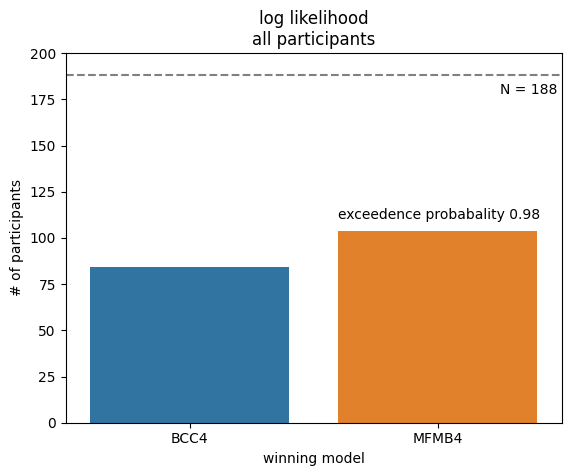

In [63]:
# plot model comparisons


plt.figure()
winning_model = BCC4_MFMB4_total_log_likes.argmin(dim=-1)
print((winning_model==0).sum().numpy())
plot_df = pd.DataFrame({"winning model": ["BCC4", "MFMB4"], 
                        "# of participants": torch.stack([(winning_model==0).sum(), (winning_model==1).sum()])})
print(plot_df)
sns.barplot(data=plot_df, y="# of participants", x="winning model")
plt.axhline(y=n_agents, color='grey', linestyle='--')
plt.text(1.25, 178, f"N = {n_agents}")
plt.text(0.6, 110, f"exceedence probabality {BCC4_MFMB4_log_likes_exc_prob:.2f}")
plt.ylim([0,200])
plt.title("log likelihood\nall participants")
plt.savefig(os.path.join(model_comp_folder, "exc_prob_llike_all.svg"))
plt.show()

110
  winning model  # of participants
0          BCC4                110
1         MFMB4                 78


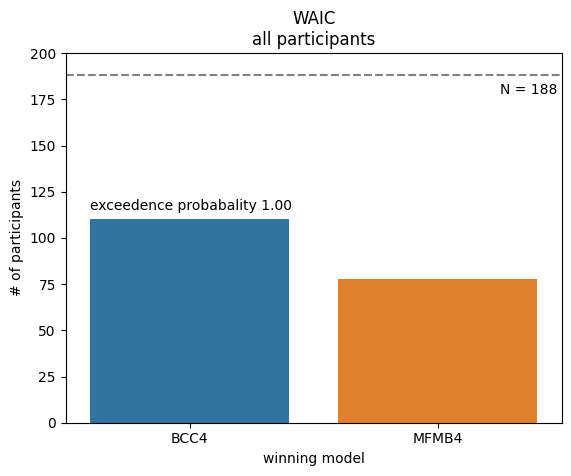

In [64]:
# plot model comparisons

plt.figure()
winning_model = BCC4_MFMB4_total_WAICs.argmin(dim=-1)
print((winning_model==0).sum().numpy())
plot_df = pd.DataFrame({"winning model": ["BCC4", "MFMB4"], 
                        "# of participants": torch.stack([(winning_model==0).sum(), (winning_model==1).sum()])})
print(plot_df)
sns.barplot(data=plot_df, y="# of participants", x="winning model")
plt.axhline(y=n_agents, color='grey', linestyle='--')
plt.text(1.25, 178, f"N = {n_agents}")
plt.text(-0.4, 115, f"exceedence probabality {BCC4_MFMB4_WAICs_exc_prob:.2f}")
plt.ylim([0,200])
plt.title("WAIC\nall participants")
plt.savefig(os.path.join(model_comp_folder, "exc_prob_waic_all.svg"))
plt.show()

65
  winning model  # of participants
0          BCC4                 65
1         MFMB4                100


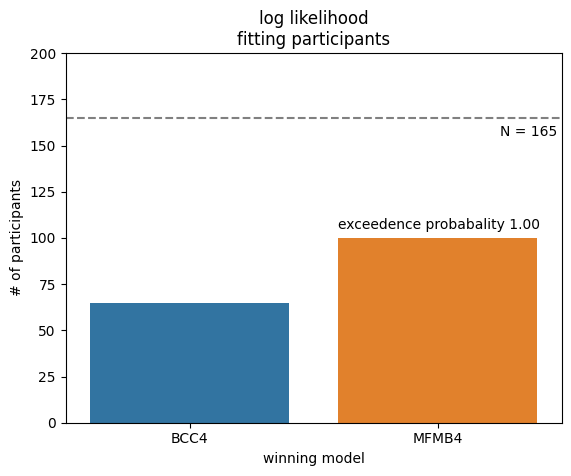

In [65]:
# plot model comparisons


plt.figure()
winning_model = BCC4_MFMB4_total_log_likes_did_fit.argmin(dim=-1)
print((winning_model==0).sum().numpy())
plot_df = pd.DataFrame({"winning model": ["BCC4", "MFMB4"], 
                        "# of participants": torch.stack([(winning_model==0).sum(), (winning_model==1).sum()])})
print(plot_df)
sns.barplot(data=plot_df, y="# of participants", x="winning model")
plt.axhline(y=did_fit.sum(), color='grey', linestyle='--')
plt.text(1.25, did_fit.sum()-10, f"N = {did_fit.sum()}")
plt.text(0.6, 105, f"exceedence probabality {BCC4_MFMB4_log_likes_exc_prob_did_fit:.2f}")
plt.ylim([0,200])
plt.title("log likelihood\nfitting participants")
plt.savefig(os.path.join(model_comp_folder, "exc_prob_llike_fitting.svg"))
plt.show()

88
  winning model  # of participants
0          BCC4                 88
1         MFMB4                 77


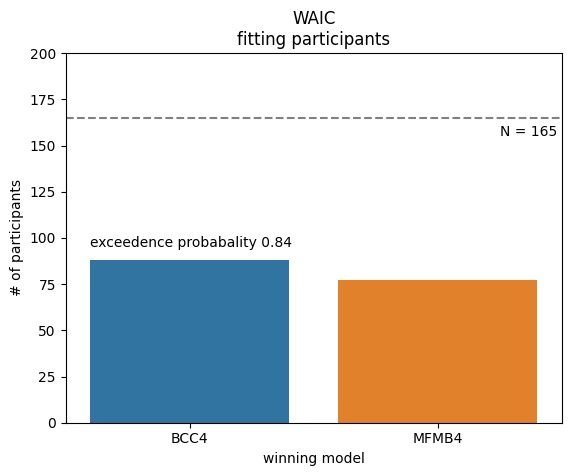

In [66]:
# plot model comparisons


plt.figure()
winning_model = BCC4_MFMB4_total_WAICs_did_fit.argmin(dim=-1)
print((winning_model==0).sum().numpy())
plot_df = pd.DataFrame({"winning model": ["BCC4", "MFMB4"], 
                        "# of participants": torch.stack([(winning_model==0).sum(), (winning_model==1).sum()])})
print(plot_df)
sns.barplot(data=plot_df, y="# of participants", x="winning model")
plt.axhline(y=did_fit.sum(), color='grey', linestyle='--')
plt.text(1.25, did_fit.sum()-10, f"N = {did_fit.sum()}")
plt.text(-0.4, 95, f"exceedence probabality {BCC4_MFMB4_WAICs_exc_prob_did_fit:.2f}")
plt.ylim([0,200])
plt.title("WAIC\nfitting participants")
plt.savefig(os.path.join(model_comp_folder, "exc_prob_waic_fitting.svg"))
plt.show()

96
  winning model  # of participants
0          BCC4                 96
1         MFMB4                 41
2         MFMB5                 51


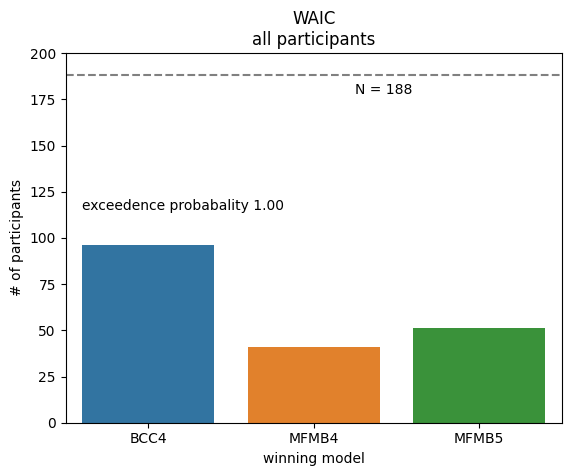

In [48]:
# plot model comparisons


plt.figure()
winning_model = BCC4_MFMB4_MFMB5_total_WAICs.argmin(dim=-1)
print((winning_model==0).sum().numpy())
plot_df = pd.DataFrame({"winning model": ["BCC4", "MFMB4", "MFMB5"], 
                        "# of participants": torch.stack([(winning_model==0).sum(), (winning_model==1).sum(), (winning_model==2).sum()])})
print(plot_df)
sns.barplot(data=plot_df, y="# of participants", x="winning model")
plt.axhline(y=n_agents, color='grey', linestyle='--')
plt.text(1.25, 178, f"N = {n_agents}")
plt.text(-0.4, 115, f"exceedence probabality {BCC4_MFMB4_MFMB5_WAICs_exc_prob:.2f}")
plt.ylim([0,200])
plt.title("WAIC\nall participants")
plt.show()

In [49]:
group_surely_BCC4 = torch.bitwise_and(BCC4_MFMB4_total_log_likes.argmin(dim=-1) == 0, BCC4_MFMB4_total_WAICs.argmin(dim=-1) == 0)
group_surely_MFMB4 = torch.bitwise_and(BCC4_MFMB4_total_log_likes.argmin(dim=-1) == 1, BCC4_MFMB4_total_WAICs.argmin(dim=-1) == 1)
group_log_MFMB4_WAIC_BCC4 = torch.bitwise_and(BCC4_MFMB4_total_log_likes.argmin(dim=-1) == 1, BCC4_MFMB4_total_WAICs.argmin(dim=-1) == 0)
group_log_BCC4_WAIC_MFMB4 = torch.bitwise_and(BCC4_MFMB4_total_log_likes.argmin(dim=-1) == 0, BCC4_MFMB4_total_WAICs.argmin(dim=-1) == 1)

print("all", BCC4_MFMB4_total_log_likes.shape[0], BCC4_MFMB4_total_WAICs.shape[0])
print("surely BCC4", group_surely_BCC4.sum())
print("surely MFMB4", group_surely_MFMB4.sum())
print("log MFMB4 waic BCC4", group_log_MFMB4_WAIC_BCC4.sum())
print("log BCC4 waic MFMB4", group_log_BCC4_WAIC_MFMB4.sum())

print("all", group_surely_BCC4.sum()+group_surely_MFMB4.sum()+group_log_MFMB4_WAIC_BCC4.sum()+group_log_BCC4_WAIC_MFMB4.sum())

all 188 188
surely BCC4 tensor(69)
surely MFMB4 tensor(63)
log MFMB4 waic BCC4 tensor(41)
log BCC4 waic MFMB4 tensor(15)
all tensor(188)


In [50]:
winning_model = []

for n in range(n_agents):
    if group_surely_BCC4[n]:
        winning_model.append("BCC4")
    elif group_surely_MFMB4[n]:
        winning_model.append("MFMB4")
    elif group_log_MFMB4_WAIC_BCC4[n]:
        winning_model.append("log MFMB4 WAIC BCC4")
    elif group_log_BCC4_WAIC_MFMB4[n]:
        winning_model.append("log BCC4 WAIC MFMB4")
print(winning_model)

['BCC4', 'MFMB4', 'BCC4', 'log MFMB4 WAIC BCC4', 'log MFMB4 WAIC BCC4', 'MFMB4', 'log MFMB4 WAIC BCC4', 'MFMB4', 'MFMB4', 'MFMB4', 'log MFMB4 WAIC BCC4', 'MFMB4', 'BCC4', 'MFMB4', 'log MFMB4 WAIC BCC4', 'log MFMB4 WAIC BCC4', 'log MFMB4 WAIC BCC4', 'log BCC4 WAIC MFMB4', 'MFMB4', 'log MFMB4 WAIC BCC4', 'BCC4', 'MFMB4', 'log MFMB4 WAIC BCC4', 'log MFMB4 WAIC BCC4', 'log MFMB4 WAIC BCC4', 'MFMB4', 'BCC4', 'MFMB4', 'BCC4', 'log MFMB4 WAIC BCC4', 'MFMB4', 'BCC4', 'log MFMB4 WAIC BCC4', 'BCC4', 'BCC4', 'log MFMB4 WAIC BCC4', 'BCC4', 'BCC4', 'log MFMB4 WAIC BCC4', 'MFMB4', 'MFMB4', 'BCC4', 'log MFMB4 WAIC BCC4', 'BCC4', 'BCC4', 'MFMB4', 'MFMB4', 'MFMB4', 'BCC4', 'MFMB4', 'log MFMB4 WAIC BCC4', 'BCC4', 'MFMB4', 'BCC4', 'BCC4', 'log MFMB4 WAIC BCC4', 'MFMB4', 'log MFMB4 WAIC BCC4', 'MFMB4', 'BCC4', 'MFMB4', 'MFMB4', 'BCC4', 'log MFMB4 WAIC BCC4', 'BCC4', 'MFMB4', 'MFMB4', 'MFMB4', 'MFMB4', 'log BCC4 WAIC MFMB4', 'MFMB4', 'log BCC4 WAIC MFMB4', 'BCC4', 'log MFMB4 WAIC BCC4', 'MFMB4', 'MFMB4', '

In [51]:
results_mean_df = pd.concat([BCC4_mean_df, MFMB4_mean_df, pd.DataFrame({"winning model": winning_model}), pd.DataFrame({"did fit": did_fit})], axis=1)

In [52]:
results_mean_df

,Unnamed: 0,inferred policy rate,subject,inferred reward rate,inferred dec temp,inferred habitual tendency,Unnamed: 0,inferred discount,subject,inferred learning rate,inferred mf weight,inferred mb weight,winning model,did fit
0,0,0.611855,0,0.163980,7.552092,0.859143,0,0.448627,0,0.497330,1.691471,1.964400,BCC4,True
1,1,0.485644,1,0.181525,7.495545,0.911870,1,0.560063,1,0.559505,2.351018,2.739979,MFMB4,True
2,2,0.459560,2,0.285278,2.278011,0.840181,2,0.321423,2,0.705197,0.845490,0.648211,BCC4,True
3,3,0.139927,3,0.039011,2.838758,0.894461,3,0.559565,3,0.197047,0.662403,0.505781,log MFMB4 WAIC BCC4,True
4,4,0.457440,4,0.369865,3.229622,0.904862,4,0.707715,4,0.499565,1.285887,0.953347,log MFMB4 WAIC BCC4,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183,183,0.579503,183,0.389000,1.342937,0.169818,183,0.203363,183,0.720747,0.580109,0.447950,BCC4,False
184,184,0.643951,184,0.296629,4.052590,0.921969,184,0.448108,184,0.654500,3.245775,2.275115,MFMB4,True
185,185,0.603069,185,0.273440,8.617109,0.880816,185,0.423943,185,0.624613,2.313950,4.092938,MFMB4,True
186,186,0.550328,186,0.242923,8.299362,0.818529,186,0.387136,186,0.563852,1.607338,2.730989,BCC4,True


In [53]:
def plot_group_bars(df, variable_of_interest, fontsize=12, only_fitting=True, annotate_pvals=False):
    model_names = ["BCC4", "MFMB4", "log MFMB4 WAIC BCC4", "log BCC4 WAIC MFMB4"]

    # test and annotate

    if only_fitting:
        working_df = df[df["did fit"]==True]
    else:
        working_df = df

    if annotate_pvals:
        vals = {}
        for name in model_names:
            vals[name] = working_df[working_df["winning model"]==name]["inferred "+variable_of_interest].values

        pairs = [("BCC4", "MFMB4"),
                ("BCC4", "log MFMB4 WAIC BCC4"),
                ("BCC4", "log BCC4 WAIC MFMB4"),
                ("MFMB4", "BCC4"),
                ("MFMB4", "log MFMB4 WAIC BCC4"),
                ("MFMB4", "log BCC4 WAIC MFMB4"),
                ("log MFMB4 WAIC BCC4", "BCC4"),
                ("log MFMB4 WAIC BCC4", "MFMB4"),
                ("log MFMB4 WAIC BCC4", "log BCC4 WAIC MFMB4"),
                ("log BCC4 WAIC MFMB4", "BCC4"),
                ("log BCC4 WAIC MFMB4", "MFMB4"),
                ("log BCC4 WAIC MFMB4", "log MFMB4 WAIC BCC4"),
                ]

        stat_results = [mannwhitneyu(vals[pair[0]], vals[pair[1]], alternative="two-sided") for pair in pairs]
        
        pvalues = [result.pvalue for result in stat_results]

        sig_pairs = []
        sig_pvalues = []
        for i,pair in enumerate(pairs):
            if pvalues[i] <= 0.05:
                sig_pairs.append(pair)
                sig_pvalues.append(pvalues[i])


    # plot
    plt.figure()
    g = sns.barplot(data=working_df, x="winning model", y="inferred "+variable_of_interest)
    g.set_xticklabels(model_names, rotation=30, fontsize=fontsize, horizontalalignment='right')
    plt.yticks(fontsize = fontsize)
    g.set_xlabel(g.get_xlabel(), fontsize=fontsize)
    g.set_ylabel(g.get_ylabel(), fontsize=fontsize)

    if annotate_pvals:
        ax = plt.gca()

        annotator = Annotator(ax, sig_pairs, data=working_df, x="winning model", y="inferred "+variable_of_interest)#, loc="outside")#, perform_stat_test=True)
        #annotator.configure(test="Mann-Whitney", comparisons_correction="bonferroni")
        #_, corrected_results = annotator.apply_and_annotate()
        annotator.set_pvalues(sig_pvalues)
        annotator.annotate()

    plt.show()

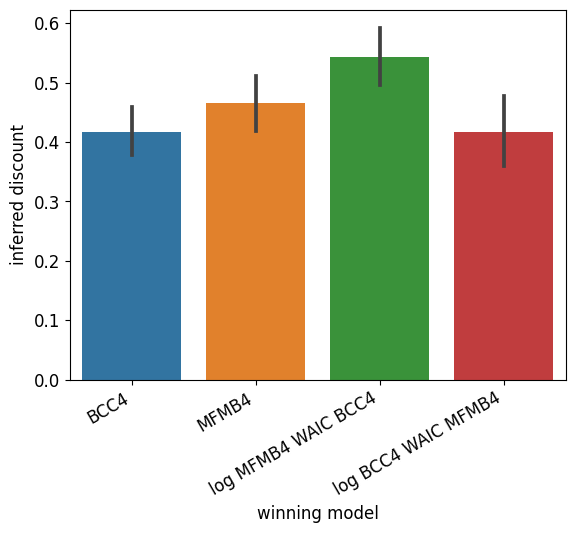

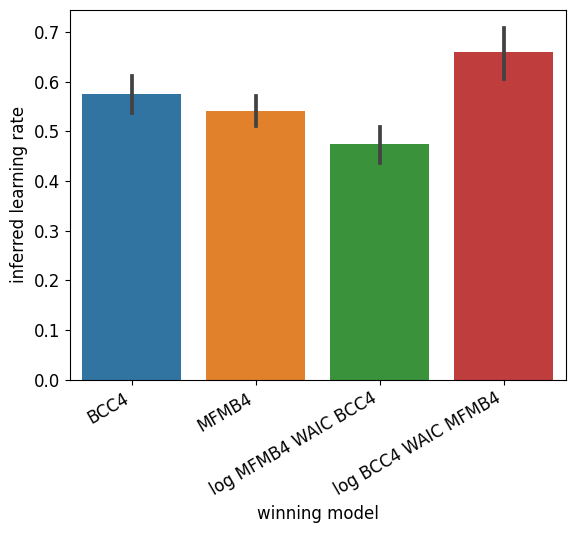

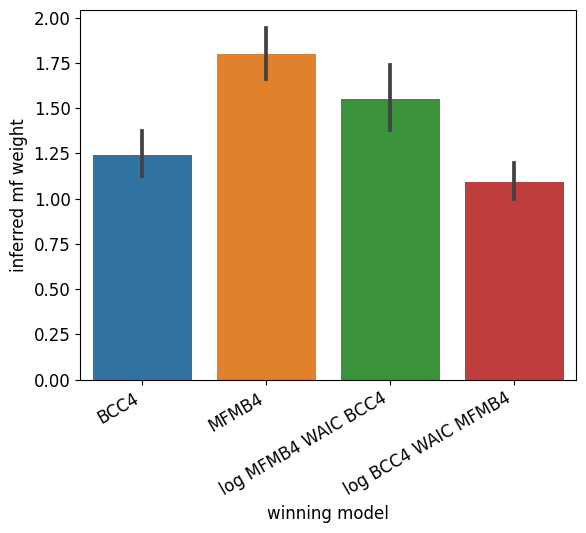

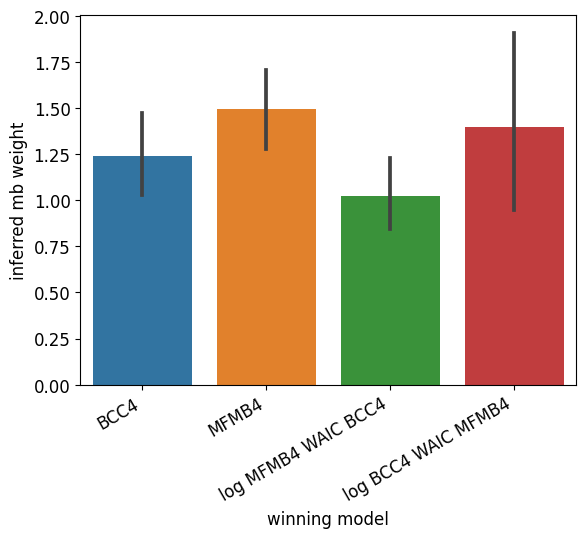

Ns tensor(50) tensor(62) tensor(38) tensor(15)


In [54]:
plot_fontsize = 12

for param in MFMB4_param_names:
    plot_group_bars(results_mean_df, param, only_fitting=True, annotate_pvals=False)

print("Ns", group_surely_BCC4[did_fit].sum(), group_surely_MFMB4[did_fit].sum(), group_log_MFMB4_WAIC_BCC4[did_fit].sum(), group_log_BCC4_WAIC_MFMB4[did_fit].sum())

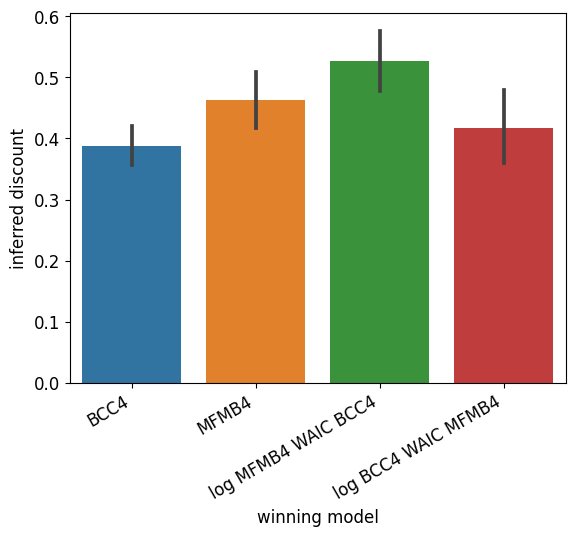

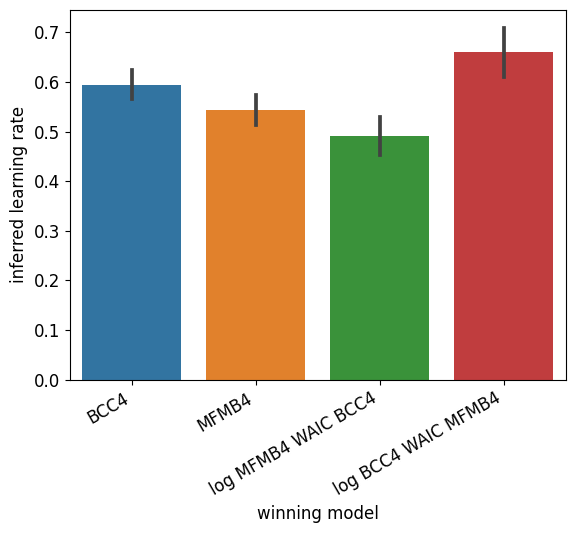

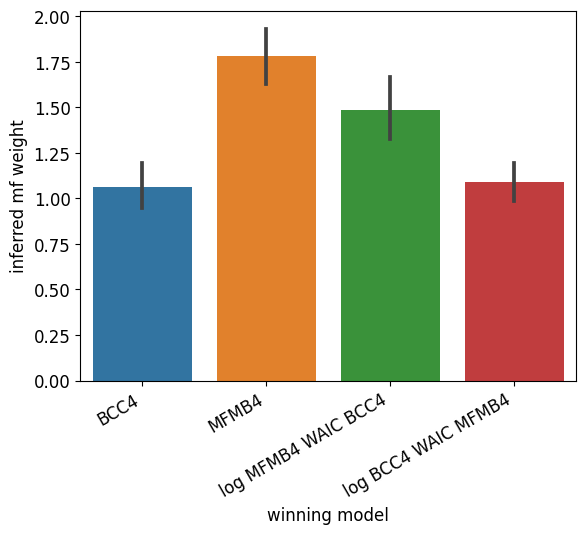

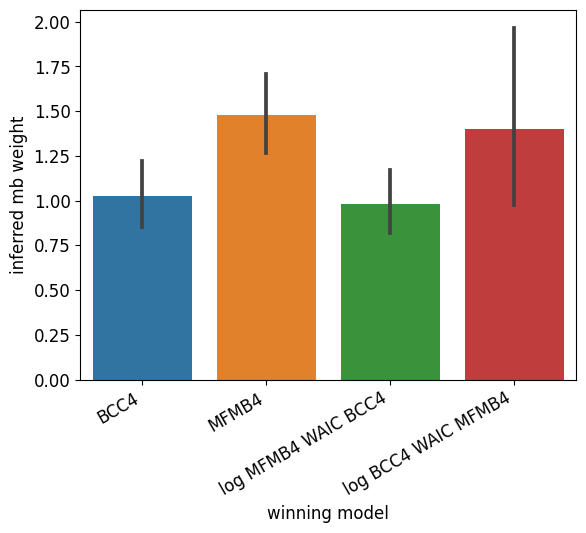

Ns tensor(69) tensor(63) tensor(41) tensor(15)


In [55]:
for param in MFMB4_param_names:
    plot_group_bars(results_mean_df, param, only_fitting=False)

print("Ns", group_surely_BCC4.sum(), group_surely_MFMB4.sum(), group_log_MFMB4_WAIC_BCC4.sum(), group_log_BCC4_WAIC_MFMB4.sum())

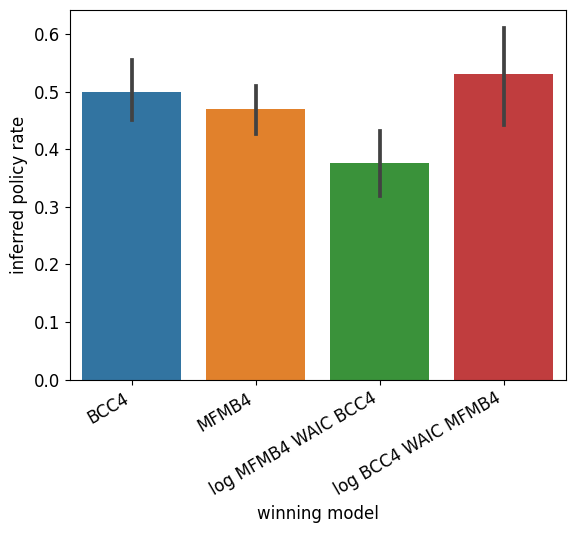

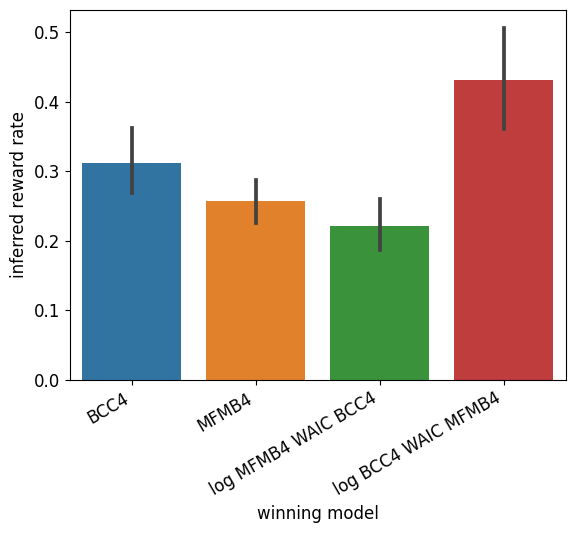

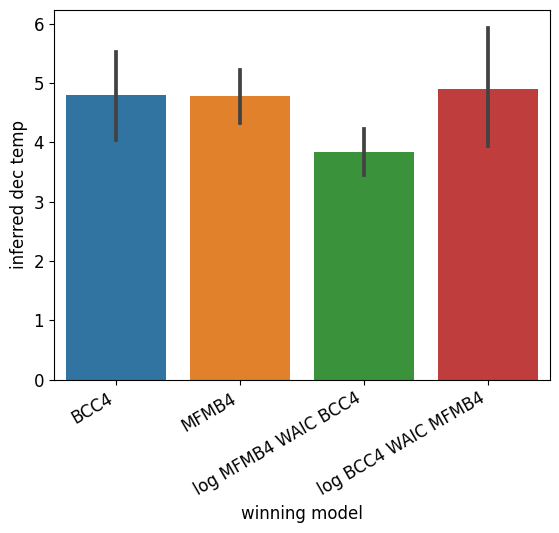

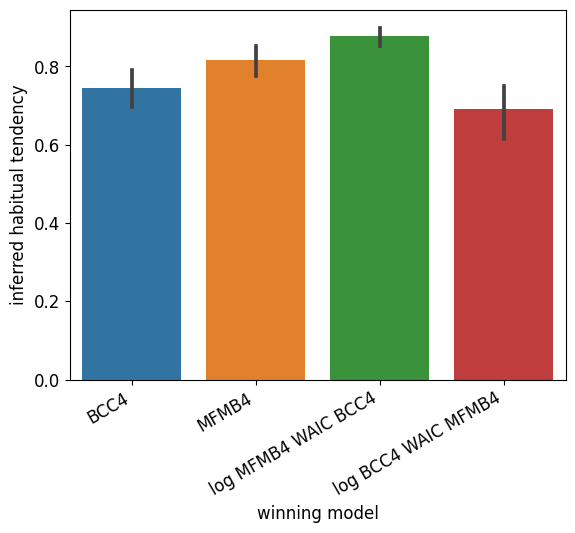

Ns tensor(50) tensor(62) tensor(38) tensor(15)


In [56]:
for param in BCC4_param_names:
    plot_group_bars(results_mean_df, param, only_fitting=True)

print("Ns", group_surely_BCC4[did_fit].sum(), group_surely_MFMB4[did_fit].sum(), group_log_MFMB4_WAIC_BCC4[did_fit].sum(), group_log_BCC4_WAIC_MFMB4[did_fit].sum())

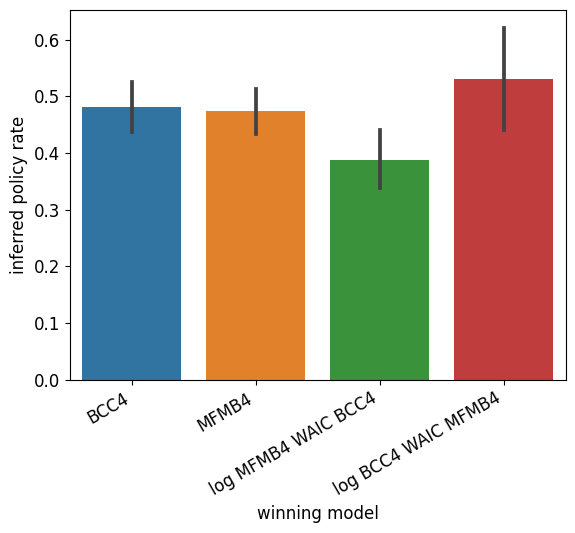

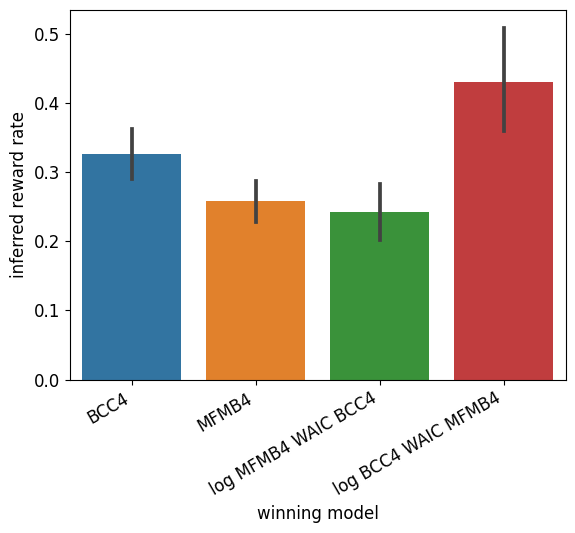

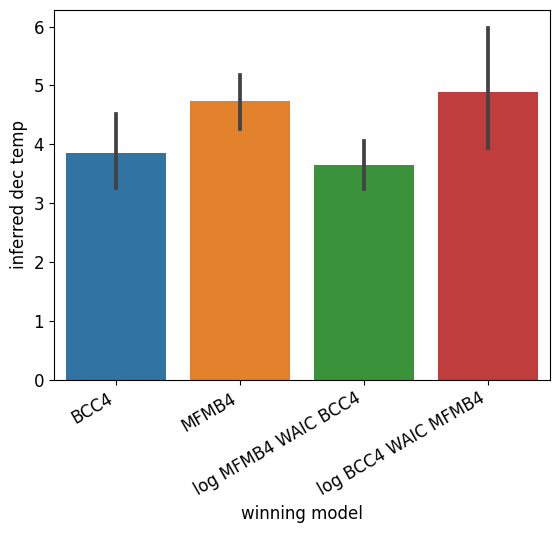

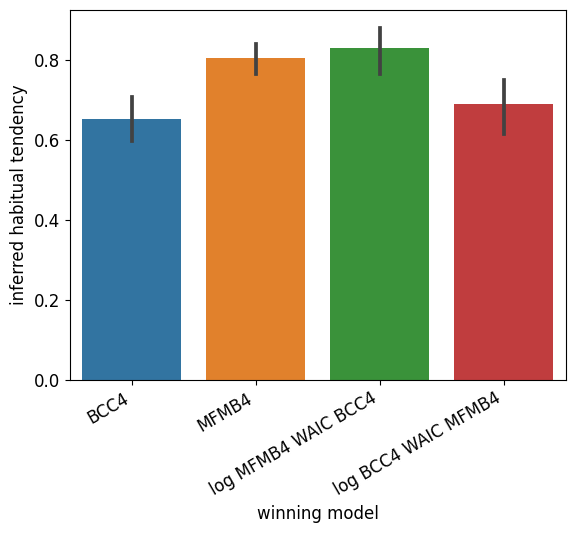

Ns tensor(69) tensor(63) tensor(41) tensor(15)


In [57]:
for param in BCC4_param_names:
    plot_group_bars(results_mean_df, param, only_fitting=False, fontsize=plot_fontsize)

print("Ns", group_surely_BCC4.sum(), group_surely_MFMB4.sum(), group_log_MFMB4_WAIC_BCC4.sum(), group_log_BCC4_WAIC_MFMB4.sum())

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:3.714e-02
MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:3.714e-02
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:5.880e-03
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:5.880e-03
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:4.650e-04
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:4.650e-04


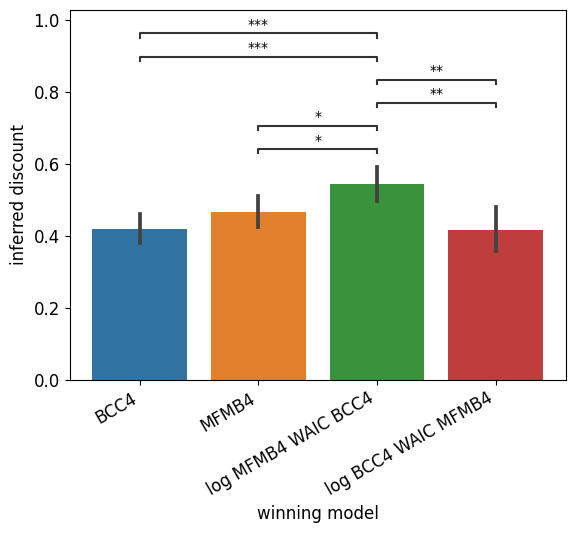

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:1.135e-02
MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:1.135e-02
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.751e-05
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.751e-05
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:1.389e-03
MFMB4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.164e-03
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:1.389e-03
MFMB4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.164e-03
BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:2.255e-02
BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:2.255e-02


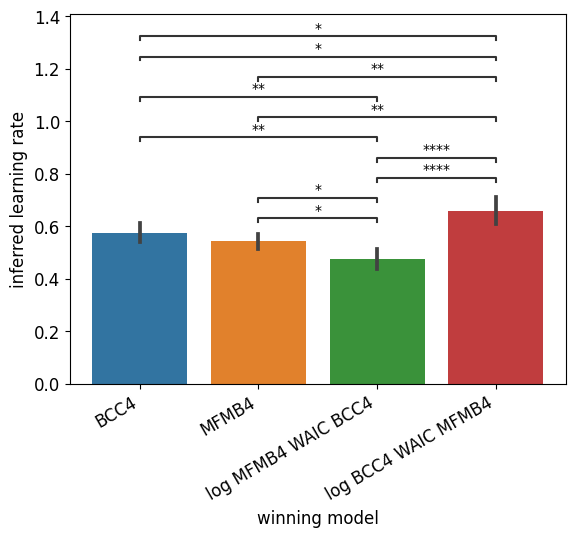

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

BCC4 vs. MFMB4: Custom statistical test, P_val:8.427e-07
BCC4 vs. MFMB4: Custom statistical test, P_val:8.427e-07
MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:3.403e-02
MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:3.403e-02
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.637e-03
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.637e-03
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:4.237e-03
MFMB4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:4.822e-06
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:4.237e-03
MFMB4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:4.822e-06


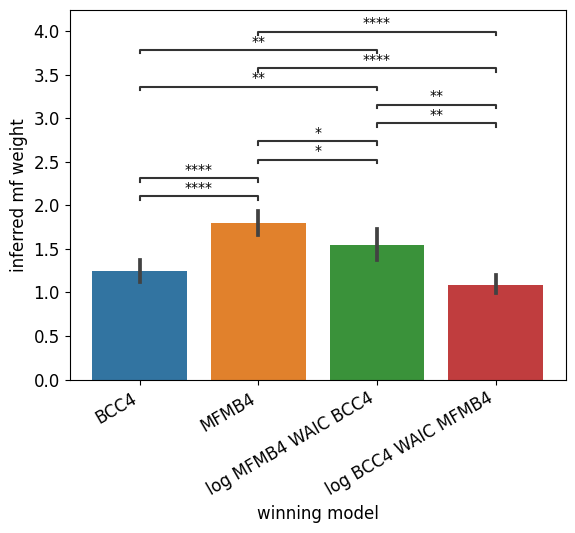

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:7.039e-03
MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:7.039e-03


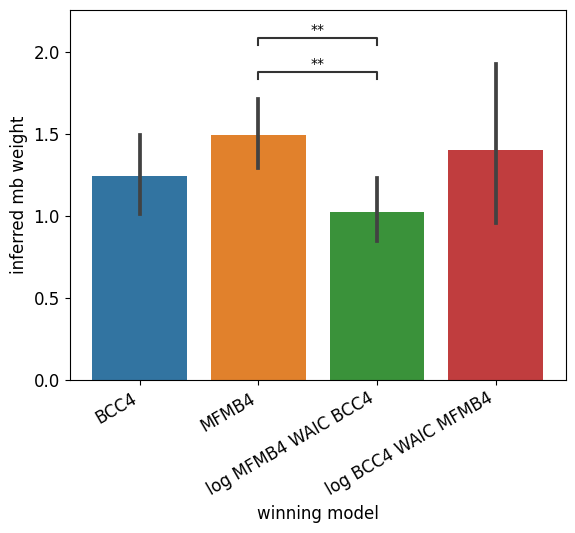

Ns tensor(50) tensor(62) tensor(38) tensor(15)


In [58]:
plot_fontsize = 12

for param in MFMB4_param_names:
    plot_group_bars(results_mean_df, param, only_fitting=True, annotate_pvals=True)

print("Ns", group_surely_BCC4[did_fit].sum(), group_surely_MFMB4[did_fit].sum(), group_log_MFMB4_WAIC_BCC4[did_fit].sum(), group_log_BCC4_WAIC_MFMB4[did_fit].sum())

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:3.714e-02
MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:3.714e-02
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:5.880e-03
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:5.880e-03
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:4.650e-04
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:4.650e-04


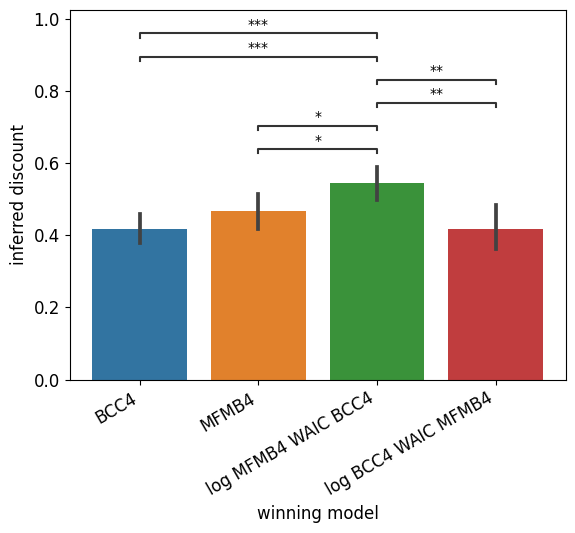

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:1.135e-02
MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:1.135e-02
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.751e-05
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.751e-05
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:1.389e-03
MFMB4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.164e-03
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:1.389e-03
MFMB4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.164e-03
BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:2.255e-02
BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:2.255e-02


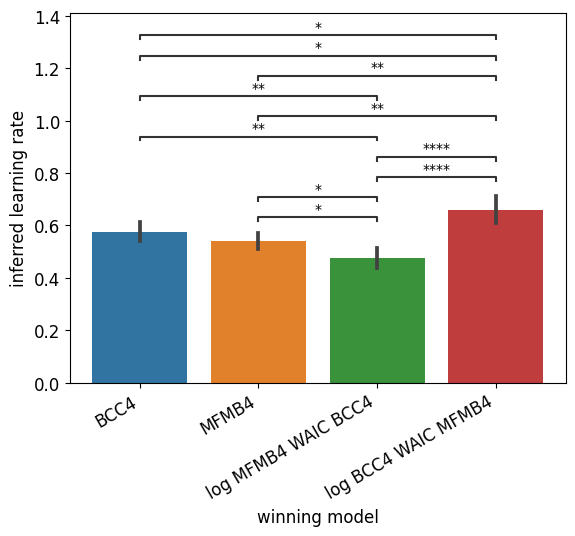

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

BCC4 vs. MFMB4: Custom statistical test, P_val:8.427e-07
BCC4 vs. MFMB4: Custom statistical test, P_val:8.427e-07
MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:3.403e-02
MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:3.403e-02
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.637e-03
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.637e-03
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:4.237e-03
MFMB4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:4.822e-06
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:4.237e-03
MFMB4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:4.822e-06


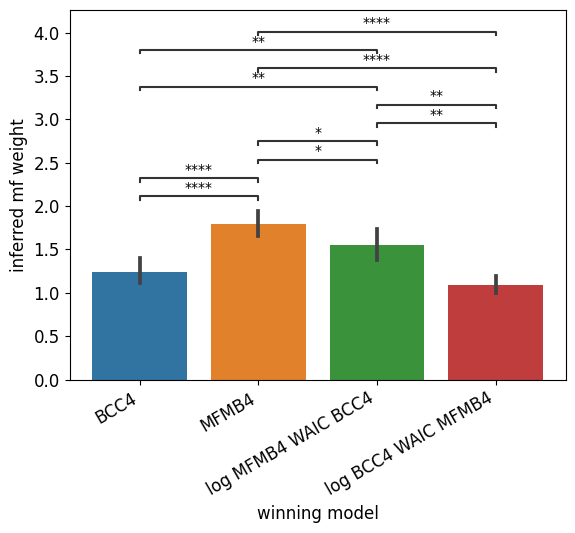

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:7.039e-03
MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:7.039e-03


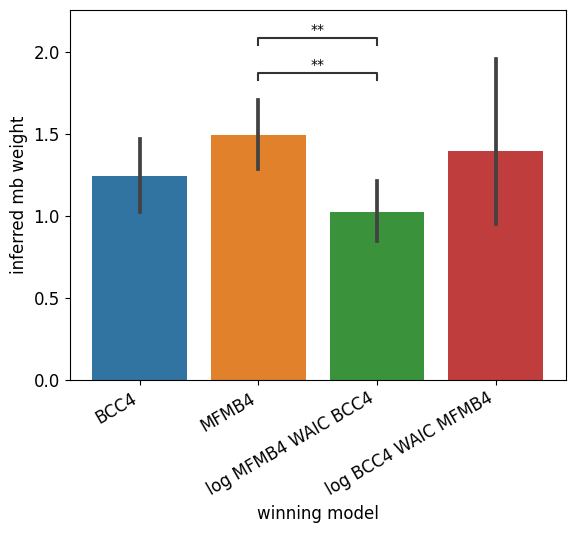

Ns tensor(50) tensor(62) tensor(38) tensor(15)


In [59]:
plot_fontsize = 12

for param in MFMB4_param_names:
    plot_group_bars(results_mean_df, param, only_fitting=True, annotate_pvals=True)

print("Ns", group_surely_BCC4[did_fit].sum(), group_surely_MFMB4[did_fit].sum(), group_log_MFMB4_WAIC_BCC4[did_fit].sum(), group_log_BCC4_WAIC_MFMB4[did_fit].sum())

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

BCC4 vs. MFMB4: Custom statistical test, P_val:2.065e-02
BCC4 vs. MFMB4: Custom statistical test, P_val:2.065e-02
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.700e-02
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.700e-02
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:3.540e-05
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:3.540e-05


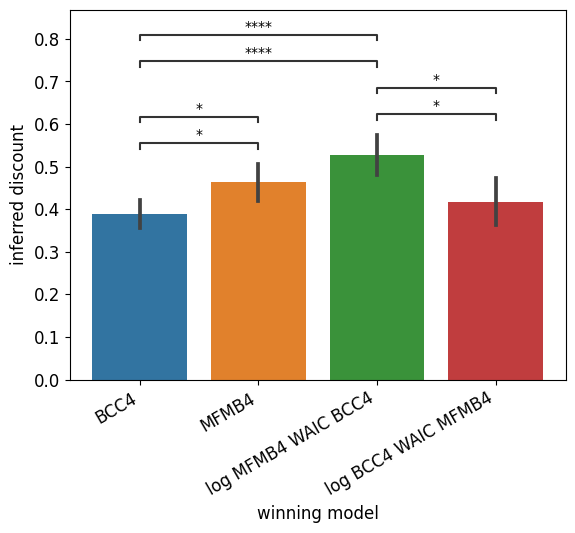

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

BCC4 vs. MFMB4: Custom statistical test, P_val:2.193e-02
BCC4 vs. MFMB4: Custom statistical test, P_val:2.193e-02
MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:4.386e-02
MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:4.386e-02
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:8.767e-05
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:8.767e-05
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:1.981e-04
MFMB4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.399e-03
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:1.981e-04
MFMB4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.399e-03


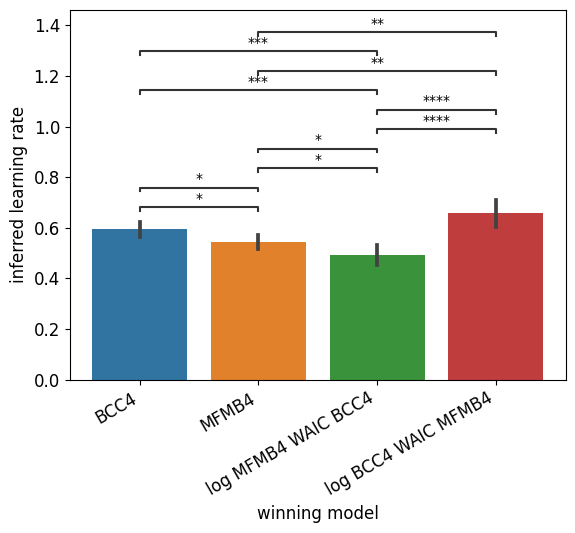

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

BCC4 vs. MFMB4: Custom statistical test, P_val:9.268e-11
BCC4 vs. MFMB4: Custom statistical test, P_val:9.268e-11
MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:1.310e-02
MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:1.310e-02
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.067e-02
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.067e-02
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:8.014e-05
MFMB4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:9.656e-06
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:8.014e-05
MFMB4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:9.656e-06


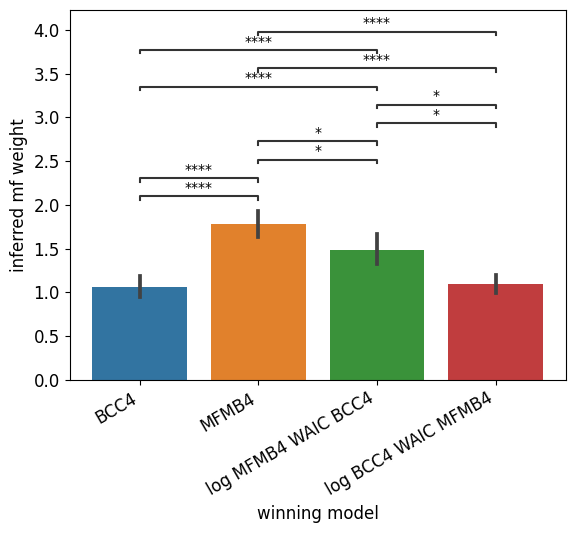

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

BCC4 vs. MFMB4: Custom statistical test, P_val:1.098e-04
BCC4 vs. MFMB4: Custom statistical test, P_val:1.098e-04
MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:2.265e-03
MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:2.265e-03
BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.089e-02
BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.089e-02


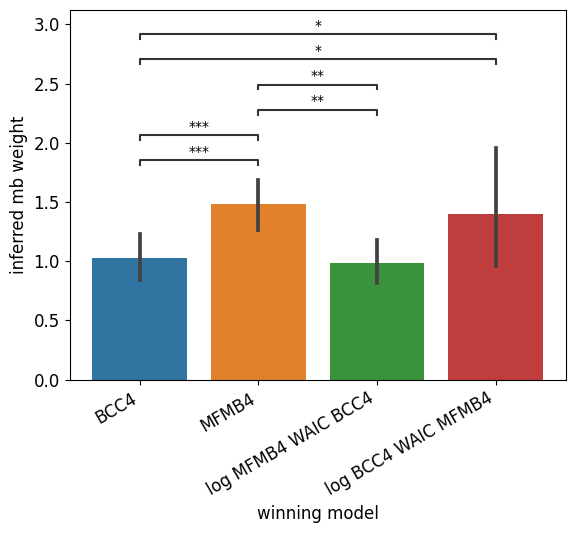

Ns tensor(69) tensor(63) tensor(41) tensor(15)


In [60]:
for param in MFMB4_param_names:
    plot_group_bars(results_mean_df, param, only_fitting=False, annotate_pvals=True)

print("Ns", group_surely_BCC4.sum(), group_surely_MFMB4.sum(), group_log_MFMB4_WAIC_BCC4.sum(), group_log_BCC4_WAIC_MFMB4.sum())

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:6.324e-03
MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:6.324e-03
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:8.891e-03
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:8.891e-03
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:3.419e-03
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:3.419e-03


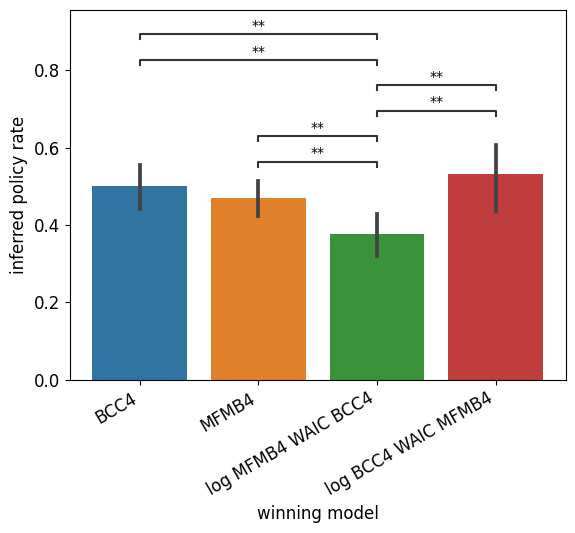

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:8.178e-05
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:8.178e-05
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:9.824e-03
MFMB4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.774e-04
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:9.824e-03
MFMB4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.774e-04
BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.547e-02
BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.547e-02


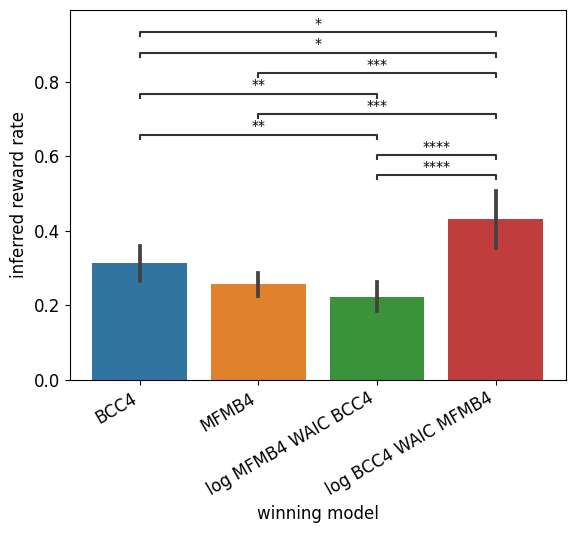

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:7.993e-03
MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:7.993e-03


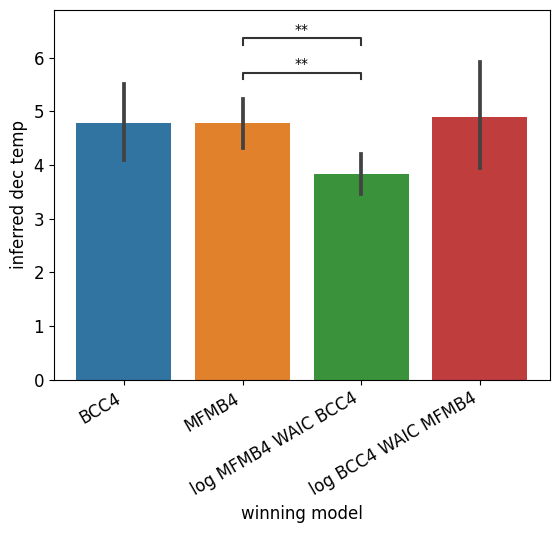

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

BCC4 vs. MFMB4: Custom statistical test, P_val:7.724e-04
BCC4 vs. MFMB4: Custom statistical test, P_val:7.724e-04
MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:2.235e-03
MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:2.235e-03
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:5.032e-07
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:5.032e-07
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:3.261e-09
MFMB4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:8.076e-05
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:3.261e-09
MFMB4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:8.076e-05
BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:4.061e-02
BCC4 vs. log BCC4 WAI

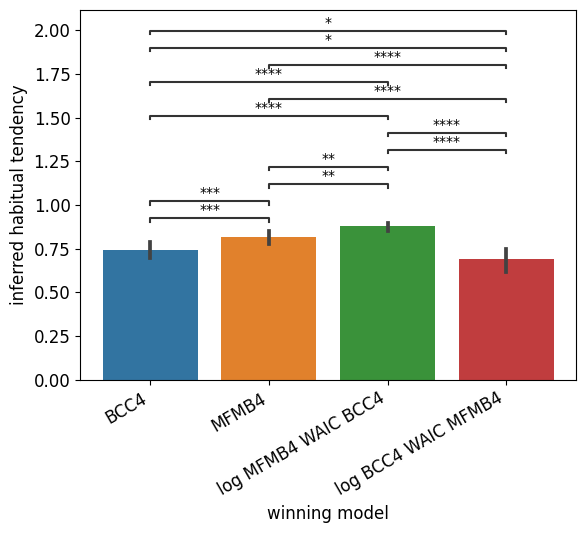

Ns tensor(50) tensor(62) tensor(38) tensor(15)


In [61]:
for param in BCC4_param_names:
    plot_group_bars(results_mean_df, param, only_fitting=True, annotate_pvals=True)

print("Ns", group_surely_BCC4[did_fit].sum(), group_surely_MFMB4[did_fit].sum(), group_log_MFMB4_WAIC_BCC4[did_fit].sum(), group_log_BCC4_WAIC_MFMB4[did_fit].sum())

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:1.170e-02
MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:1.170e-02
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.460e-02
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.460e-02
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:9.943e-03
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:9.943e-03


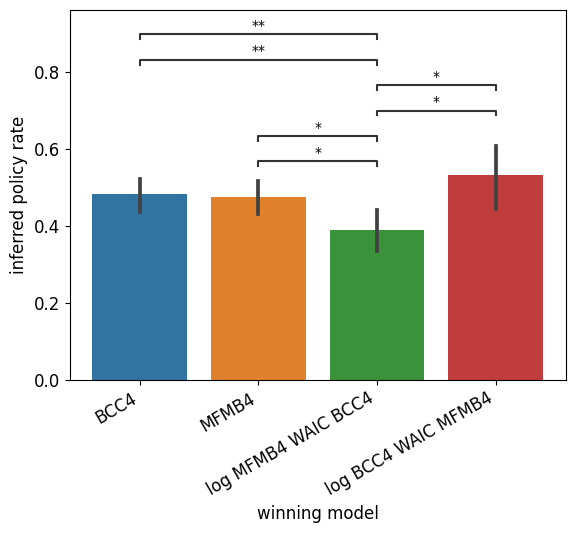

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

BCC4 vs. MFMB4: Custom statistical test, P_val:1.556e-02
BCC4 vs. MFMB4: Custom statistical test, P_val:1.556e-02
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:4.392e-04
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:4.392e-04
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:6.408e-03
MFMB4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.662e-04
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:6.408e-03
MFMB4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.662e-04
BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:2.648e-02
BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:2.648e-02


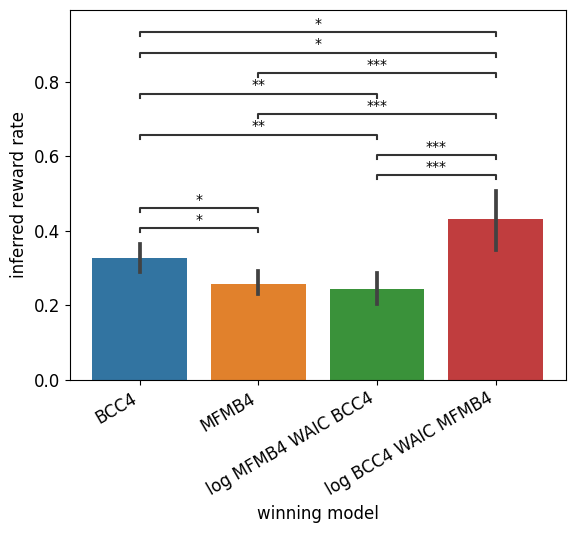

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

BCC4 vs. MFMB4: Custom statistical test, P_val:6.266e-03
BCC4 vs. MFMB4: Custom statistical test, P_val:6.266e-03
MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:3.010e-03
MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:3.010e-03
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:2.902e-02
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:2.902e-02


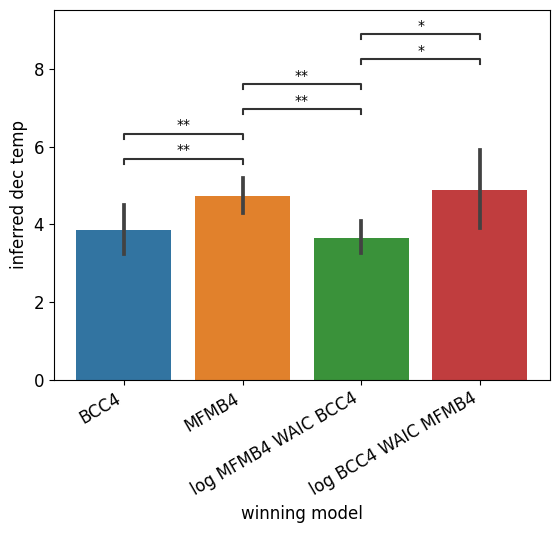

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

BCC4 vs. MFMB4: Custom statistical test, P_val:1.309e-06
BCC4 vs. MFMB4: Custom statistical test, P_val:1.309e-06
MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:1.788e-02
MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:1.788e-02
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.626e-05
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.626e-05
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:2.534e-09
MFMB4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.502e-04
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:2.534e-09
MFMB4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.502e-04


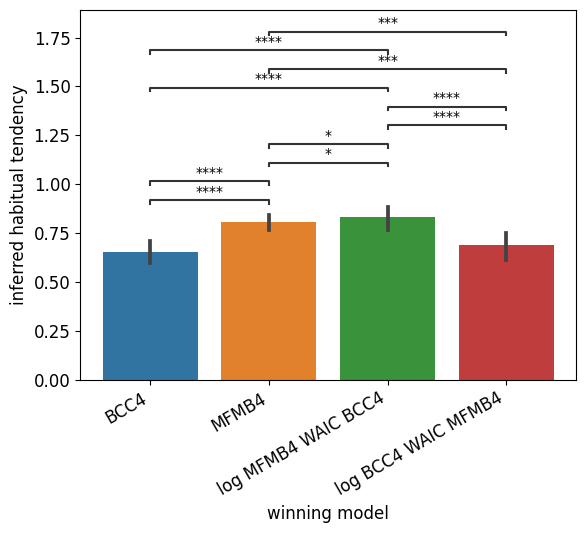

Ns tensor(69) tensor(63) tensor(41) tensor(15)


In [62]:
for param in BCC4_param_names:
    plot_group_bars(results_mean_df, param, only_fitting=False, fontsize=plot_fontsize, annotate_pvals=True)

print("Ns", group_surely_BCC4.sum(), group_surely_MFMB4.sum(), group_log_MFMB4_WAIC_BCC4.sum(), group_log_BCC4_WAIC_MFMB4.sum())